In [16]:
df = pd.read_csv('C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_enriquecidos.csv')

In [17]:
df.head()

,IG_EST,IG_DEP,IG_MUN,IG_POB,IG_LAT_W84,IG_LON_W84,D_PR_PAL1,D_MI_PAL1,D_CLAS_DEP,R_RO_HUES,...,Moho_Z_var,Bario_ppm_best,Azufre_ppm_best,Cromo_ppm_best,Plata_ppm_best,Bismuto_ppm_best,Mercurio_ppm_best,Antimonio_ppm_best,X,Y
0,Ocurrencia,Caldas,Neira,Neira,5.157379,-75.605610,Crisotilo-Mg3Si2O5(OH)4,Crisotilo-Mg3(Si2O5)(OH)4,Asociado_a_magmas_máficos_básicos,ROCA_METAMÓRFICA,...,8.732556,477.712156,198.159524,211.462227,0.243344,0.126327,0.000064,0.338982,-75.605610,5.157379
1,Productor - Cielo abierto,Caldas,Filadelfia,Filadelfia,5.330765,-75.555830,Crisotilo-Mg3Si2O5(OH)4,Crisotilo-Mg3(Si2O5)(OH)4,Asociado_a_magmas_máficos_básicos,ROCA_METAMÓRFICA,...,8.379028,156.130692,2756.142412,626.253742,0.111306,0.147930,0.000119,0.681167,-75.555830,5.330765
2,Productor - Cielo abierto,Caldas,La Merced,La Merced,5.385162,-75.563087,Talco-Mg3Si4O10(OH)2,Talco-Mg3Si4O10(OH)2,Asociado_a_magmas_máficos_básicos,ROCA_METAMÓRFICA,...,7.071767,438.038816,1735.063449,1046.971263,0.142589,0.115326,0.004203,1.085799,-75.563087,5.385162
3,Productor - Cielo abierto,Caldas,La Merced,La Merced,5.401767,-75.554080,Crisotilo-Mg3Si2O5(OH)4,Crisotilo-Mg3(Si2O5)(OH)4,Asociado_a_magmas_máficos_básicos,ROCA_METAMÓRFICA,...,6.362132,727.956927,1927.835158,253.896558,0.150558,0.122527,0.016713,1.516182,-75.554080,5.401767
4,Productor - Cielo abierto,Caldas,Aguadas,Pácora,5.537187,-75.467920,Crisotilo-Mg3Si2O5(OH)4,Crisotilo-Mg3(Si2O5)(OH)4,Asociado_a_magmas_máficos_básicos,ROCA_ÍGNEA_PLUTÓNICA,...,3.261513,160.252664,1467.574207,201.684877,0.105968,0.100213,0.004635,0.134417,-75.467920,5.537187


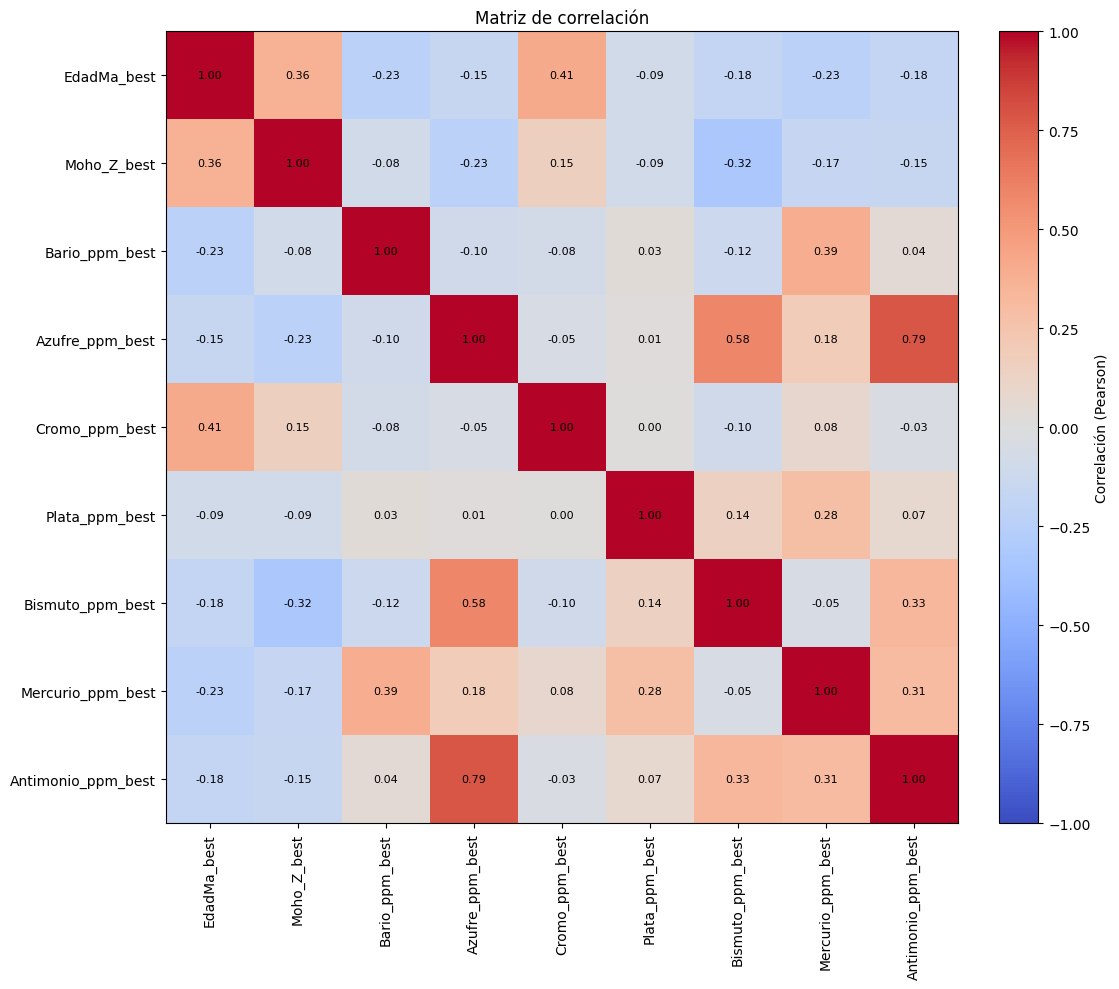

Heatmap guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\matriz_correlacion_heatmap.png


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- 1) Lee tu CSV ----
csv_path = r"C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_enriquecidos.csv"
df = pd.read_csv(csv_path)

# ---- 2) Selecciona solo variables numéricas y elimina columnas no deseadas ----
cols_drop = ["X", "Y", "IG_LAT_W84", "IG_LON_W84", "Moho_Z_var"]
df_num = df.select_dtypes(include=[np.number]).drop(columns=[c for c in cols_drop if c in df.columns], errors="ignore")

# ---- 3) Calcula la matriz de correlación ----
corr = df_num.corr(method="pearson")

# ---- 4) Heatmap con anotaciones ----
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

# Ticks y etiquetas
ax.set_xticks(np.arange(corr.shape[1]))
ax.set_yticks(np.arange(corr.shape[0]))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)

# Anotar cada celda con el valor
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iat[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=8)

# Barra de color y título
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlación (Pearson)")
ax.set_title("Matriz de correlación")

plt.tight_layout()

# ---- 5) Guardar a PNG ----
out_png = r"C:\Git_SCA\AGE\Codigo\salidas_fast\matriz_correlacion_heatmap.png"
plt.savefig(out_png, dpi=300)
plt.show()

print("Heatmap guardado en:", out_png)


<Axes: >

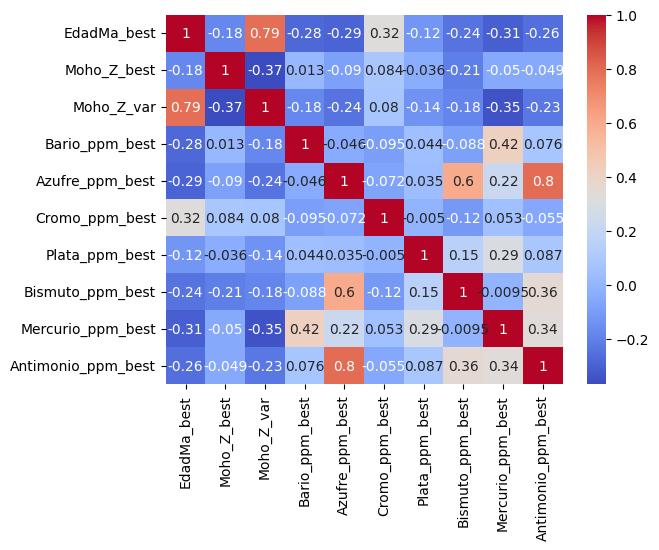

In [39]:
import seaborn as sns
corr = df_all[X_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True)


In [84]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix, precision_recall_fscore_support
)
import matplotlib.pyplot as plt
from pathlib import Path

# ===========================================================
# CONFIGURACIÓN
# ===========================================================
csv_path           = r"C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_enriquecidos.csv"
departamentos_path = r"C:\Git_SCA\AGE\departramentos_c"

out_dir            = Path(r"C:\Git_SCA\AGE\Codigo\salidas_fast")
out_dir.mkdir(parents=True, exist_ok=True)

out_coef_csv       = out_dir / "logreg_coeficientes_revisado.csv"
out_corr_png       = out_dir / "correlaciones_heatmap.png"

random_state       = 42

# Negativos
neg_ratio          = 1.0   # nº de negativos por cada positivo
k_idw              = 8     # k vecinos para IDW
p_idw              = 2     # potencia IDW

# Columnas a excluir de los predictores
cols_drop          = ["X", "Y", "IG_LAT_W84", "IG_LON_W84", "label"]

# ===========================================================
# Helpers
# ===========================================================
def guess_points_crs(x, y):
    """Heurística simple: si luce como grados, asumimos EPSG:4326; si no, None."""
    if (np.nanmax(np.abs(x)) <= 180) and (np.nanmax(np.abs(y)) <= 90):
        return "EPSG:4326"
    return None

def plot_corr_heatmap(df_num, out_png):
    corr = df_num.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.iat[i,j]:.2f}", ha="center", va="center", fontsize=6)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlación (Pearson)")
    ax.set_title("Matriz de correlación")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def _loglik_binaria(y, p):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

def _pseudo_r2(y, p_hat, k_params):
    n = len(y)
    ll_model = _loglik_binaria(y, p_hat)
    p_null   = np.repeat(y.mean(), n)
    ll_null  = _loglik_binaria(y, p_null)

    r2_mcf    = 1 - (ll_model / ll_null)
    r2_mcfadj = 1 - (ll_model - k_params) / ll_null

    Lm = np.exp(ll_model)
    L0 = np.exp(ll_null)
    r2_cs  = 1 - (L0 / Lm) ** (2.0 / n)
    r2_nag = r2_cs / (1 - (L0) ** (2.0 / n))

    r2_tjur = p_hat[y == 1].mean() - p_hat[y == 0].mean()
    y_bar   = y.mean()
    r2_ef   = 1 - np.sum((y - p_hat)**2) / np.sum((y - y_bar)**2)

    return {
        "McFadden": r2_mcf,
        "McFadden_ajustado": r2_mcfadj,
        "Cox_Snell": r2_cs,
        "Nagelkerke": r2_nag,
        "Tjur": r2_tjur,
        "Efron": r2_ef,
        "LogLik_Modelo": ll_model,
        "LogLik_Nulo": ll_null
    }

# ===========================================================
# 1) Cargar positivos
# ===========================================================
df_pos = pd.read_csv(csv_path)
if not {"X", "Y"}.issubset(df_pos.columns):
    raise ValueError("El CSV debe tener columnas 'X' y 'Y' para generar negativos.")
df_pos["label"] = 1

# Variables numéricas
num_cols = df_pos.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in num_cols if c not in cols_drop]

# ===========================================================
# 2) CRS
# ===========================================================
gdf_dep = gpd.read_file(departamentos_path)
crs_dep = gdf_dep.crs
print("CRS departamentos:", crs_dep)

crs_guess = guess_points_crs(df_pos["X"].values, df_pos["Y"].values)
if crs_guess is None:
    print("Asumo que X/Y ya están en el CRS de departamentos.")
    gdf_pos = gpd.GeoDataFrame(df_pos, geometry=gpd.points_from_xy(df_pos["X"], df_pos["Y"]), crs=crs_dep)
else:
    print("X/Y parecen estar en grados. Asumo", crs_guess, "y reproyecto a CRS de departamentos.")
    gdf_pos_4326 = gpd.GeoDataFrame(df_pos, geometry=gpd.points_from_xy(df_pos["X"], df_pos["Y"]), crs=crs_guess)
    gdf_pos = gdf_pos_4326.to_crs(crs_dep)

df_pos["X_proj"] = gdf_pos.geometry.x
df_pos["Y_proj"] = gdf_pos.geometry.y

# ===========================================================
# 3) Generar pseudo-negativos
# ===========================================================
poly = gdf_dep.unary_union
n_pos = len(df_pos)
n_neg = int(n_pos * neg_ratio)
minx, miny, maxx, maxy = poly.bounds
rng = np.random.default_rng(random_state)
xs, ys = [], []
while len(xs) < n_neg:
    xr = rng.uniform(minx, maxx)
    yr = rng.uniform(miny, maxy)
    if poly.contains(Point(xr, yr)):
        xs.append(xr)
        ys.append(yr)

df_neg_xy = pd.DataFrame({"X_proj": xs, "Y_proj": ys})

# ===========================================================
# 4) IDW para pseudo-negativos
# ===========================================================
X_src_xy   = df_pos[["X_proj", "Y_proj"]].values
X_src_vals = df_pos[X_cols].values
nbrs = NearestNeighbors(n_neighbors=min(k_idw, len(df_pos)), algorithm="kd_tree").fit(X_src_xy)
dist, idx = nbrs.kneighbors(df_neg_xy[["X_proj", "Y_proj"]].values)
dist = np.where(dist == 0, 1e-12, dist)
w = 1.0 / (dist ** p_idw)
w = w / w.sum(axis=1, keepdims=True)
X_neg_vals = np.einsum("ij,ijk->ik", w, X_src_vals[idx])

df_neg = pd.DataFrame(X_neg_vals, columns=X_cols)
df_neg["X_proj"] = df_neg_xy["X_proj"].values
df_neg["Y_proj"] = df_neg_xy["Y_proj"].values
df_neg["label"] = 0

# ===========================================================
# 5) Dataset final
# ===========================================================
df_all = pd.concat(
    [df_pos[["label", "X_proj", "Y_proj"] + X_cols],
     df_neg[["label", "X_proj", "Y_proj"] + X_cols]],
    ignore_index=True
)
X = df_all[X_cols]
y = df_all["label"].astype(int)

# ===========================================================
# 6) Heatmap
# ===========================================================
plot_corr_heatmap(X, out_corr_png)
print(f"✔ Heatmap de correlación guardado en: {out_corr_png}")

# ===========================================================
# 7) Train/Test split
# ===========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)

# ===========================================================
# 8) Pipeline
# ===========================================================
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",  # solo L2
        penalty="l2"
    ))
])

param_grid = {
    "logreg__C": [1e-4, 1e-3, 1e-2, 0.1, 1.0]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
gs = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)

print("Mejores hiperparámetros:", gs.best_params_)
print("AUC-ROC (CV mejor modelo):", gs.best_score_)

# ===========================================================
# 9) Evaluación en test con reporte mejorado
# ===========================================================
best_model = gs.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
cm = confusion_matrix(y_test, y_pred)

print("\n--- MÉTRICAS EN TEST ---")
print(f"AUC-ROC   : {auc:.3f}")
print(f"Precisión : {prec:.3f}")
print(f"Recall    : {rec:.3f}")
print(f"F1-score  : {f1:.3f}")
print("Matriz de confusión:\n", cm)

# Crear DataFrame de métricas
metricas_df = pd.DataFrame({
    "Métrica": ["AUC-ROC", "Precisión", "Recall", "F1-score"],
    "Valor": [auc, prec, rec, f1]
})

# Guardar métricas en CSV
out_metricas_csv = out_dir / "metricas_logit.csv"
metricas_df.to_csv(out_metricas_csv, index=False)

# Reporte de coeficientes (top 10)
coefs = best_model.named_steps["logreg"].coef_.ravel()
feat_importance = (
    pd.DataFrame({
        "Variable": X.columns,
        "Coeficiente": coefs,
        "Importancia_absoluta": np.abs(coefs),
        "Signo": np.sign(coefs)
    })
    .sort_values("Importancia_absoluta", ascending=False)
)

top10_coef = feat_importance.head(10)
out_coef_csv = out_dir / "coeficientes_logit_top10.csv"
top10_coef.to_csv(out_coef_csv, index=False)

# Mostrar métricas y coeficientes para el informe
print("\n=== Resumen de métricas ===")
print(metricas_df)
print("\n=== Top 10 coeficientes ===")
print(top10_coef)

# ===========================================================
# 11) Curva ROC (visual mejorada)
# ===========================================================
fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}", lw=2)
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / "curva_roc_logit.png", dpi=300)
plt.show()

# ===========================================================
# 12) Mapa de puntos
# ===========================================================
gdf_all = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all["X_proj"], df_all["Y_proj"]),
    crs=crs_dep
)
gdf_pos_plot = gdf_all[gdf_all["label"] == 1]
gdf_neg_plot = gdf_all[gdf_all["label"] == 0]
fig, ax = plt.subplots(figsize=(10, 10))
gdf_dep.plot(ax=ax, color="white", edgecolor="black")
gdf_neg_plot.plot(ax=ax, color="red", markersize=15, label="Negativos (0)", alpha=0.6)
gdf_pos_plot.plot(ax=ax, color="blue", markersize=15, label="Positivos (1)", alpha=0.8)
plt.legend()
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.title("Eventos positivos y pseudo-negativos (CRS corregido)")
plt.tight_layout()
plt.savefig(out_dir / "mapa_eventos.png", dpi=300)
plt.show()


TypeError: SimpleImputer.__init__() takes 1 positional argument but 2 were given

CRS departamentos: EPSG:9377
X/Y parecen estar en grados. Asumo EPSG:4326 y reproyecto a CRS de departamentos.
✔ Heatmap de correlación guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\correlaciones_heatmap.png
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejores hiperparámetros: {'logreg__C': 1.0}
AUC-ROC (CV mejor modelo): 0.7446145124716553

--- MÉTRICAS EN TEST ---
AUC-ROC: 0.8103401360544218

Classification report:
               precision    recall  f1-score   support

           0       0.76      0.71      0.74       105
           1       0.73      0.77      0.75       105

    accuracy                           0.74       210
   macro avg       0.74      0.74      0.74       210
weighted avg       0.74      0.74      0.74       210

Confusion matrix:
 [[75 30]
 [24 81]]
Precision: 0.730 | Recall: 0.771 | F1: 0.750

=== Top 20 coeficientes (por |valor|) ===
             variable      coef  abs_coef  signo
0         EdadMa_best -0.997431  0.997431   -1.0
1         

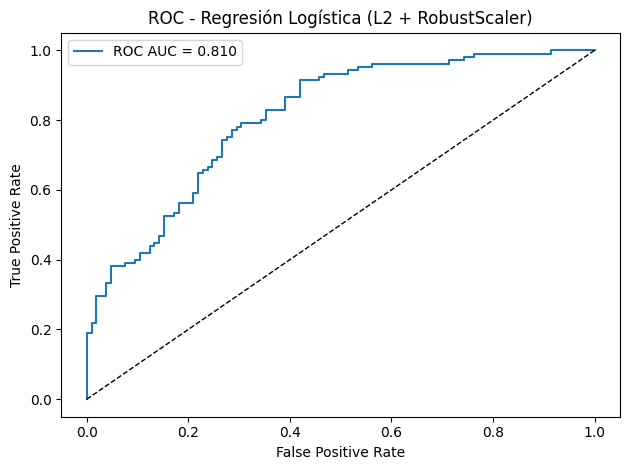

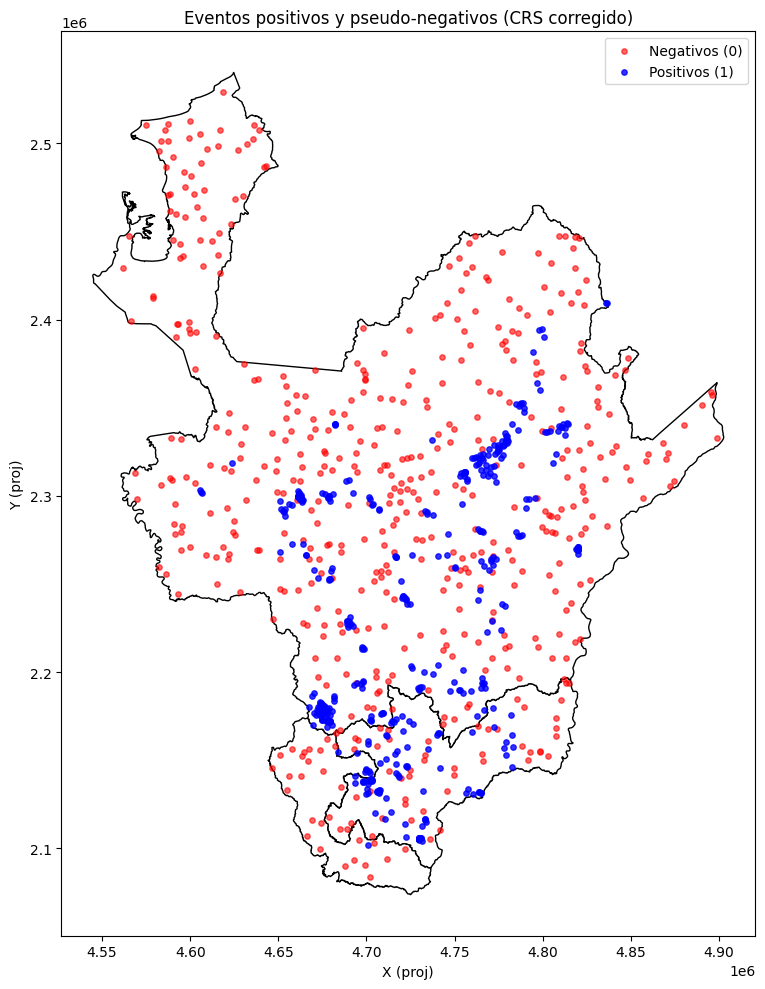


--- MORAN'S I (residuales TRAIN, Logit base) ---
Moran's I: 0.351317
p-value (normalidad): 0.000000


In [93]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix, precision_recall_fscore_support
)
import matplotlib.pyplot as plt
from pathlib import Path

# ===========================================================
# CONFIGURACIÓN
# ===========================================================
csv_path           = r"C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_enriquecidos.csv"
departamentos_path = r"C:\Git_SCA\AGE\departramentos_c"

out_dir            = Path(r"C:\Git_SCA\AGE\Codigo\salidas_fast")
out_dir.mkdir(parents=True, exist_ok=True)

out_coef_csv       = out_dir / "logreg_coeficientes_revisado.csv"
out_corr_png       = out_dir / "correlaciones_heatmap.png"

random_state       = 42

# Negativos
neg_ratio          = 1.0   # nº de negativos por cada positivo
k_idw              = 8     # k vecinos para IDW
p_idw              = 2     # potencia IDW

# Columnas a excluir de los predictores
cols_drop          = ["X", "Y", "IG_LAT_W84", "IG_LON_W84", "label"]

# ===========================================================
# Helpers
# ===========================================================
def guess_points_crs(x, y):
    """Heurística simple: si luce como grados, asumimos EPSG:4326; si no, None."""
    if (np.nanmax(np.abs(x)) <= 180) and (np.nanmax(np.abs(y)) <= 90):
        return "EPSG:4326"
    return None

def plot_corr_heatmap(df_num, out_png):
    corr = df_num.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.iat[i,j]:.2f}", ha="center", va="center", fontsize=6)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlación (Pearson)")
    ax.set_title("Matriz de correlación")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# ===========================================================
# 1) Cargar positivos, crear label=1
# ===========================================================
df_pos = pd.read_csv(csv_path)
if not {"X", "Y"}.issubset(df_pos.columns):
    raise ValueError("El CSV debe tener columnas 'X' y 'Y' para generar negativos.")

df_pos["label"] = 1

# Variables numéricas candidatas
num_cols = df_pos.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in num_cols if c not in cols_drop]

# ===========================================================
# 2) CRS: leer departamentos y llevar puntos al mismo CRS
# ===========================================================
gdf_dep = gpd.read_file(departamentos_path)
crs_dep = gdf_dep.crs
print("CRS departamentos:", crs_dep)

# Intentamos inferir el CRS de tus X/Y
crs_guess = guess_points_crs(df_pos["X"].values, df_pos["Y"].values)
if crs_guess is None:
    # Asumimos que ya vienen en el CRS de departamentos
    print("Asumo que X/Y ya están en el CRS de departamentos.")
    gdf_pos = gpd.GeoDataFrame(df_pos, geometry=gpd.points_from_xy(df_pos["X"], df_pos["Y"]), crs=crs_dep)
else:
    print("X/Y parecen estar en grados. Asumo", crs_guess, "y reproyecto a CRS de departamentos.")
    gdf_pos_4326 = gpd.GeoDataFrame(df_pos, geometry=gpd.points_from_xy(df_pos["X"], df_pos["Y"]), crs=crs_guess)
    gdf_pos = gdf_pos_4326.to_crs(crs_dep)

# Reemplazamos X/Y por las coordenadas proyectadas (para que todo lo siguiente sea consistente)
df_pos["X_proj"] = gdf_pos.geometry.x
df_pos["Y_proj"] = gdf_pos.geometry.y

# ===========================================================
# 3) Generar pseudo-negativos en TODO el departamento (CRS = dep)
# ===========================================================
poly = gdf_dep.unary_union
n_pos = len(df_pos)
n_neg = int(n_pos * neg_ratio)

minx, miny, maxx, maxy = poly.bounds
rng = np.random.default_rng(random_state)

xs, ys = [], []
while len(xs) < n_neg:
    xr = rng.uniform(minx, maxx)
    yr = rng.uniform(miny, maxy)
    if poly.contains(Point(xr, yr)):
        xs.append(xr)
        ys.append(yr)

df_neg_xy = pd.DataFrame({"X_proj": xs, "Y_proj": ys})

# ===========================================================
# 4) Imputar variables a negativos vía IDW kNN (rápido, pero puede sesgar)
# ===========================================================
X_src_xy   = df_pos[["X_proj", "Y_proj"]].values
X_src_vals = df_pos[X_cols].values

nbrs = NearestNeighbors(n_neighbors=min(k_idw, len(df_pos)), algorithm="kd_tree").fit(X_src_xy)
dist, idx = nbrs.kneighbors(df_neg_xy[["X_proj", "Y_proj"]].values)

dist = np.where(dist == 0, 1e-12, dist)
w = 1.0 / (dist ** p_idw)
w = w / w.sum(axis=1, keepdims=True)

X_neg_vals = np.einsum("ij,ijk->ik", w, X_src_vals[idx])

df_neg = pd.DataFrame(X_neg_vals, columns=X_cols)
df_neg["X_proj"] = df_neg_xy["X_proj"].values
df_neg["Y_proj"] = df_neg_xy["Y_proj"].values
df_neg["label"] = 0

# ===========================================================
# 5) Dataset final para modelar
# ===========================================================
df_all = pd.concat(
    [df_pos[["label", "X_proj", "Y_proj"] + X_cols],
     df_neg[["label", "X_proj", "Y_proj"] + X_cols]],
    ignore_index=True
)

# Solo features (sin coords) para entrenar
X = df_all[X_cols]
y = df_all["label"].astype(int)

# ===========================================================
# 6) Heatmap de correlación
# ===========================================================
plot_corr_heatmap(X, out_corr_png)
print(f"✔ Heatmap de correlación guardado en: {out_corr_png}")

# ===========================================================
# 7) Train/Test split
# ===========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)

# ===========================================================
# 8) Pipeline: Imputer + RobustScaler + LogReg L2
# ===========================================================
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",  # solo L2
        penalty="l2"
    ))
])

param_grid = {
    "logreg__C": [1e-4, 1e-3, 1e-2, 0.1, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

gs = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)

print("Mejores hiperparámetros:", gs.best_params_)
print("AUC-ROC (CV mejor modelo):", gs.best_score_)

# ===========================================================
# 9) Evaluación en test
# ===========================================================
best_model = gs.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

print("\n--- MÉTRICAS EN TEST ---")
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

# ===========================================================
# 10) Coeficientes ordenados
# ===========================================================
coefs = best_model.named_steps["logreg"].coef_.ravel()
feat_importance = (
    pd.DataFrame({
        "variable": X.columns,
        "coef": coefs,
        "abs_coef": np.abs(coefs),
        "signo": np.sign(coefs)
    })
    .sort_values("abs_coef", ascending=False)
)
feat_importance.to_csv(out_coef_csv, index=False)
print("\n=== Top 20 coeficientes (por |valor|) ===")
print(feat_importance.head(20))
print(f"\n✔ Coeficientes guardados en: {out_coef_csv}")

# ===========================================================
# 11) Curva ROC
# ===========================================================
fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Regresión Logística (L2 + RobustScaler)")
plt.legend()
plt.tight_layout()
plt.show()

# ===========================================================
# 12) Mapa (CRS corregido)
# ===========================================================
gdf_all = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all["X_proj"], df_all["Y_proj"]),
    crs=crs_dep
)

gdf_pos_plot = gdf_all[gdf_all["label"] == 1]
gdf_neg_plot = gdf_all[gdf_all["label"] == 0]

fig, ax = plt.subplots(figsize=(10, 10))
gdf_dep.plot(ax=ax, color="white", edgecolor="black")
gdf_neg_plot.plot(ax=ax, color="red", markersize=15, label="Negativos (0)", alpha=0.6)
gdf_pos_plot.plot(ax=ax, color="blue", markersize=15, label="Positivos (1)", alpha=0.8)

plt.legend()
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.title("Eventos positivos y pseudo-negativos (CRS corregido)")
plt.tight_layout()
plt.show()


# =========================
# Moran's I de residuales (TRAIN)
# =========================
from libpysal.weights import KNN
from esda.moran import Moran

# Probabilidades en TRAIN
y_proba_train = best_model.predict_proba(X_train)[:, 1]
resid_train   = y_train.values - y_proba_train  # residuales (y - p̂)

# Coordenadas de los puntos de TRAIN
coords_train = df_all.loc[X_train.index, ["X_proj", "Y_proj"]].values

# Matriz de pesos espacial KNN
k_w = 8  # ajústalo si quieres
w_train = KNN.from_array(coords_train, k=k_w)
w_train.transform = "r"  # estandarización por filas

# Moran's I
mi = Moran(resid_train, w_train, two_tailed=False)
print("\n--- MORAN'S I (residuales TRAIN, Logit base) ---")
print(f"Moran's I: {mi.I:.6f}")
print(f"p-value (normalidad): {mi.p_norm:.6f}")



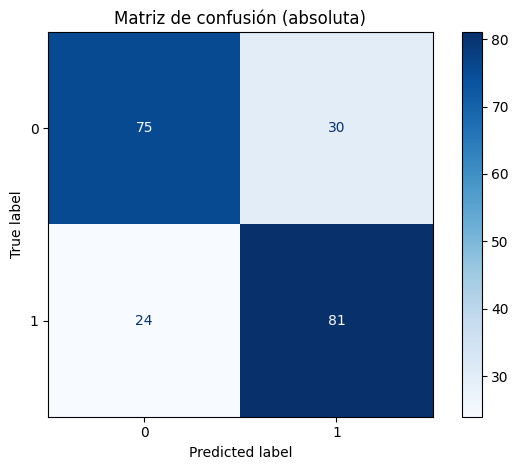

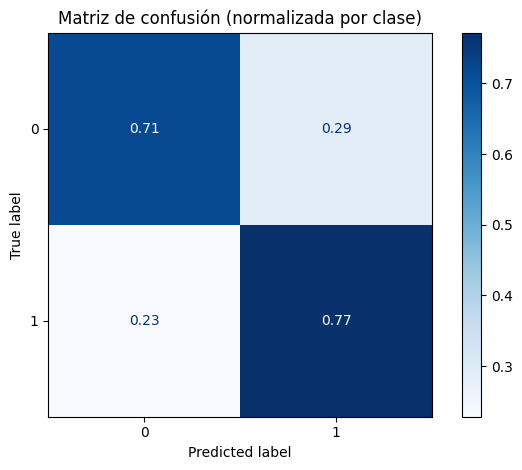

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# y_test, y_pred ya calculados
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión (absoluta)")
plt.tight_layout()
plt.show()

# Normalizada por la verdad (recall por clase)
cm_norm = confusion_matrix(y_test, y_pred, labels=[0, 1], normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=[0, 1])
disp_norm.plot(cmap="Blues", values_format=".2f")
plt.title("Matriz de confusión (normalizada por clase)")
plt.tight_layout()
plt.show()


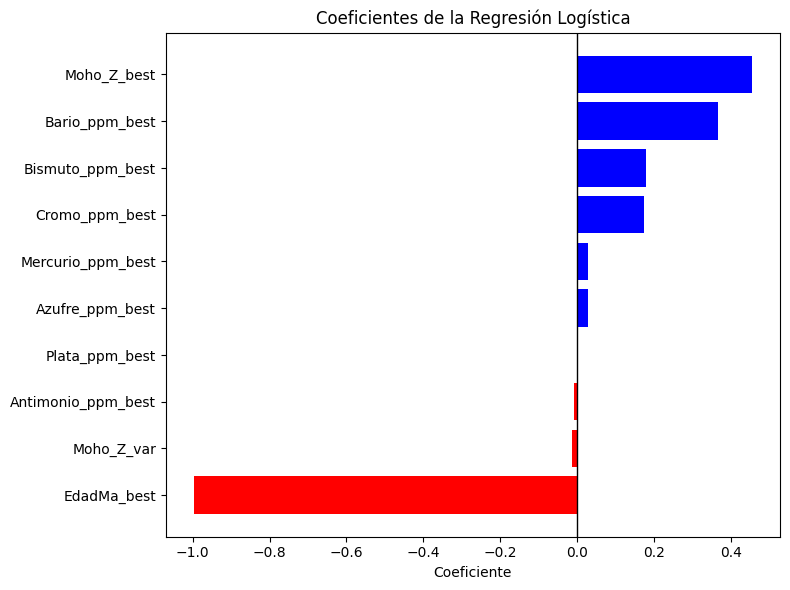

In [44]:
import matplotlib.pyplot as plt

# feat_importance es el DataFrame que generamos con las variables y coeficientes
# Si no lo tienes, créalo así:
# coefs = best_model.named_steps["logreg"].coef_.ravel()
# feat_importance = pd.DataFrame({
#     "variable": X.columns,
#     "coef": coefs
# }).sort_values("coef", ascending=False)

# Ordenar por valor absoluto de coeficiente
feat_plot = feat_importance.sort_values("coef", ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(feat_plot["variable"], feat_plot["coef"], color=(feat_plot["coef"] > 0).map({True: 'blue', False: 'red'}))
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Coeficiente")
plt.title("Coeficientes de la Regresión Logística")
plt.tight_layout()
plt.show()


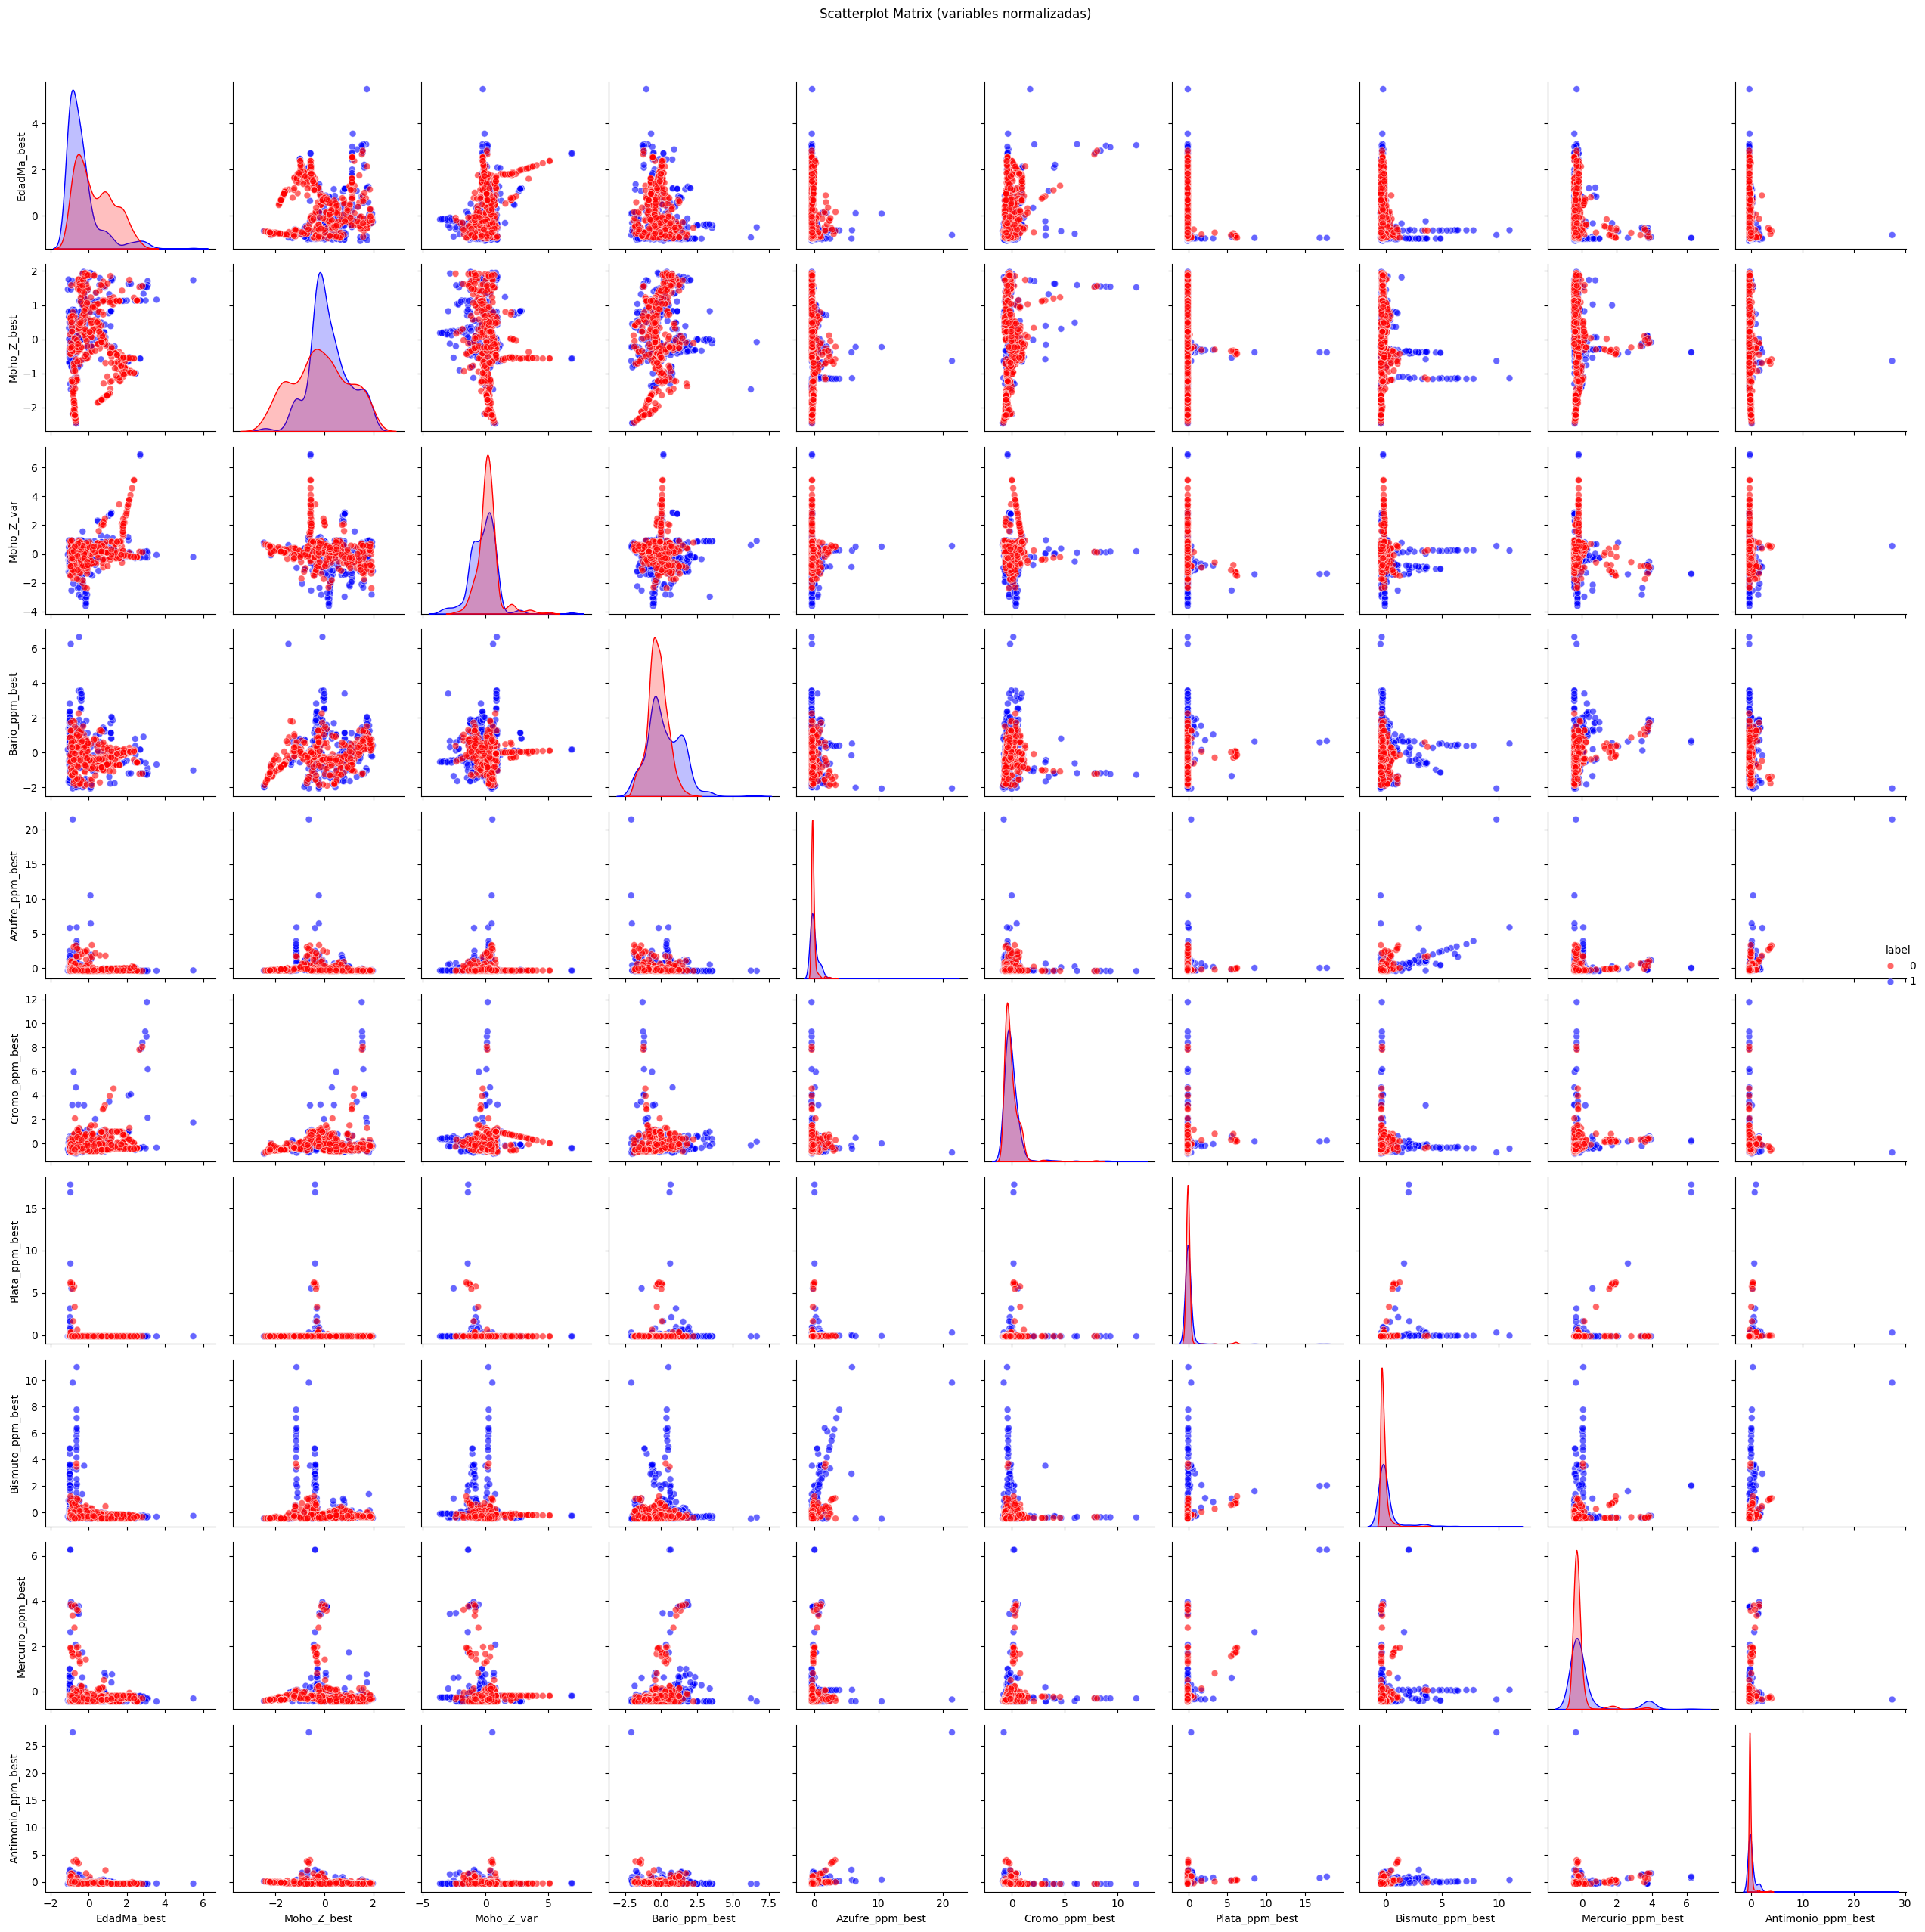

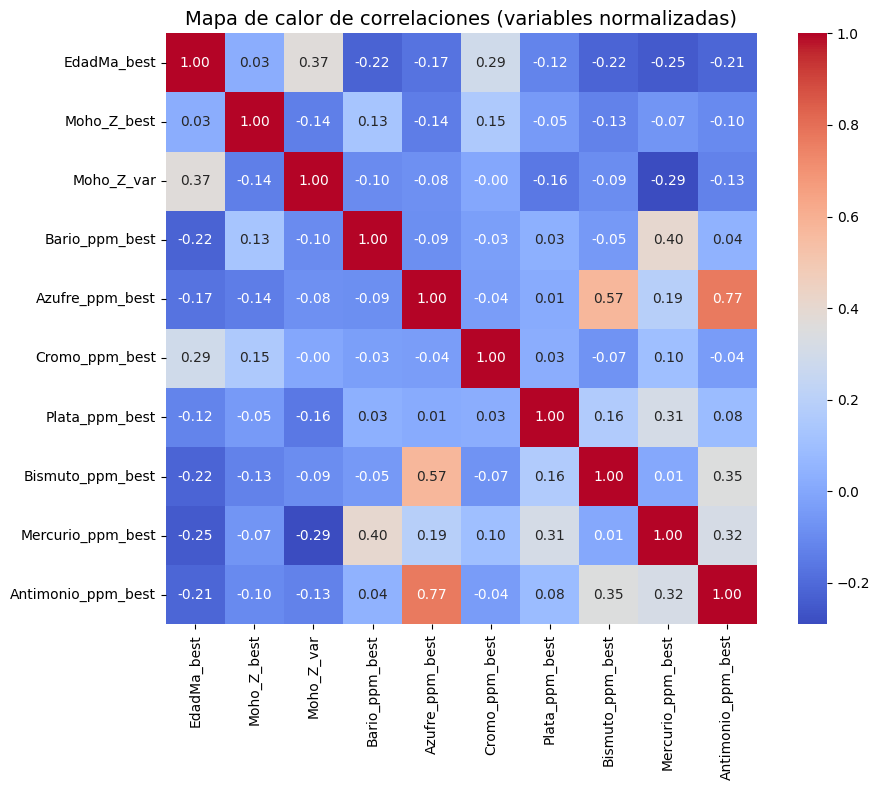

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler  # o RobustScaler

# ==========================================================
# 1) Normalizar variables
# ==========================================================
scaler = StandardScaler()
X_norm = pd.DataFrame(
    scaler.fit_transform(df_all[X_cols]),
    columns=X_cols,
    index=df_all.index
)

# DataFrame con label
df_plot = pd.concat([X_norm, df_all["label"]], axis=1)

# ==========================================================
# 2) Pairplot (scatterplot matrix)
# ==========================================================
sns.pairplot(
    df_plot,
    hue="label",
    palette={0: "red", 1: "blue"},
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 40}
)

plt.suptitle("Scatterplot Matrix (variables normalizadas)", y=20)
plt.tight_layout()
plt.show()

# ==========================================================
# 3) Mapa de calor de correlaciones
# ==========================================================
plt.figure(figsize=(10, 8))
corr_matrix = X_norm.corr()

sns.heatmap(
    corr_matrix,
    annot=True,        # Mostrar valores
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True
)

plt.title("Mapa de calor de correlaciones (variables normalizadas)", fontsize=14)
plt.tight_layout()
plt.show()


In [46]:
import pandas as pd

# Archivo de salida
out_csv_events = r"C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_pos_neg.csv"

# Guardar el DataFrame completo con variables y label
df_all.to_csv(out_csv_events, index=False)

print(f"✔ Archivo exportado con eventos positivos y negativos: {out_csv_events}")


✔ Archivo exportado con eventos positivos y negativos: C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_pos_neg.csv


In [51]:
dff=pd.read_csv("C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_pos_neg.csv")
dff.tail()

,label,X_proj,Y_proj,EdadMa_best,Moho_Z_best,Moho_Z_var,Bario_ppm_best,Azufre_ppm_best,Cromo_ppm_best,Plata_ppm_best,Bismuto_ppm_best,Mercurio_ppm_best,Antimonio_ppm_best
1045,0,4.756694e+06,2.426501e+06,246.983597,42.805120,10.091377,586.599364,282.844751,285.367907,0.125108,0.397675,0.060806,0.633928
1046,0,4.589088e+06,2.332810e+06,36.594619,34.959336,9.340032,297.313580,307.812749,57.555329,0.243901,0.083196,0.018680,3.958976
1047,0,4.758238e+06,2.443388e+06,278.751858,42.485010,12.885564,607.484757,280.767138,244.905278,0.130909,0.372194,0.060688,0.835799
1048,0,4.743716e+06,2.212515e+06,132.108463,53.203118,9.388654,808.301464,354.134527,102.587987,0.218948,0.252132,0.067314,2.285943
1049,0,4.693970e+06,2.324497e+06,218.267493,41.786174,8.947195,532.193206,840.028045,118.544761,0.150750,0.089309,0.027252,0.465112


Fitting 5 folds for each of 5 candidates, totalling 25 fits

========== MODELO BASE ==========
  Métrica     BASE
  AUC-ROC 0.810340
 Accuracy 0.742857
Precisión 0.729730
   Recall 0.771429
 F1-score 0.750000

Pseudo-R² (BASE):
        Pseudo-R2       Valor
         McFadden    0.238471
McFadden_ajustado    0.162901
        Cox_Snell    0.281501
       Nagelkerke    0.375335
             Tjur    0.247782
            Efron    0.290404
    LogLik_Modelo -110.848857
      LogLik_Nulo -145.560908

Matriz de confusión (BASE):
[[75 30]
 [24 81]]

Top 10 coeficientes (BASE):
             variable      coef  abs_coef
0         EdadMa_best -0.997431  0.997431
1         Moho_Z_best  0.454682  0.454682
3      Bario_ppm_best  0.365630  0.365630
7    Bismuto_ppm_best  0.178706  0.178706
5      Cromo_ppm_best  0.173192  0.173192
8   Mercurio_ppm_best  0.028448  0.028448
4     Azufre_ppm_best  0.027121  0.027121
2          Moho_Z_var -0.012939  0.012939
9  Antimonio_ppm_best -0.007437  0.007437
6    

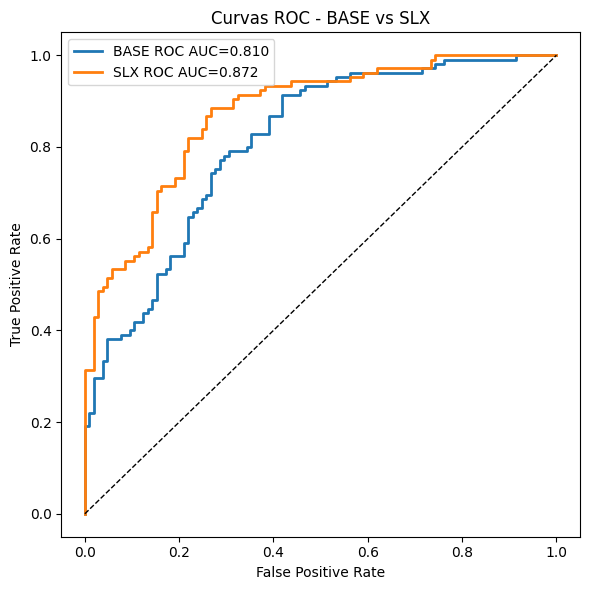

In [88]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)
import matplotlib.pyplot as plt
from pathlib import Path

# Para SLX
from libpysal.weights import KNN
# (Moran lo importas si luego quieres usarlo con los residuales)
# from esda.moran import Moran

# ===========================================================
# CONFIGURACIÓN
# ===========================================================
csv_path           = r"C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_enriquecidos.csv"
departamentos_path = r"C:\Git_SCA\AGE\departramentos_c"

out_dir = Path(r"C:\Git_SCA\AGE\Codigo\salidas_fast")
out_dir.mkdir(parents=True, exist_ok=True)

# Paths de salida
out_corr_png_base  = out_dir / "correlaciones_heatmap_base.png"
out_coef_csv_base  = out_dir / "logreg_coeficientes_base.csv"
out_corr_png_slx   = out_dir / "correlaciones_heatmap_slx.png"
out_coef_csv_slx   = out_dir / "logreg_coeficientes_slx.csv"

random_state = 42
neg_ratio    = 1.0  # negativos/positivos
k_idw        = 8
p_idw        = 2
k_w          = 8  # vecinos para W

cols_drop = ["X", "Y", "IG_LAT_W84", "IG_LON_W84", "label"]

# ===========================================================
# Helpers
# ===========================================================
def guess_points_crs(x, y):
    if (np.nanmax(np.abs(x)) <= 180) and (np.nanmax(np.abs(y)) <= 90):
        return "EPSG:4326"
    return None

def plot_corr_heatmap(df, path, title="Matriz de correlación"):
    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10,8))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.iat[i,j]:.2f}", ha="center", va="center", fontsize=6)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlación (Pearson)")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.close()

def _loglik_binaria(y, p):
    eps = 1e-12
    p = np.clip(p, eps, 1-eps)
    return np.sum(y*np.log(p) + (1-y)*np.log(1-p))

def _pseudo_r2(y, p_hat, k_params):
    n = len(y)
    ll_m = _loglik_binaria(y, p_hat)
    p_null = np.repeat(y.mean(), n)
    ll_0 = _loglik_binaria(y, p_null)

    r2_mcf     = 1 - ll_m/ll_0
    r2_mcf_adj = 1 - (ll_m - k_params)/ll_0

    Lm, L0 = np.exp(ll_m), np.exp(ll_0)
    r2_cs  = 1 - (L0/Lm)**(2.0/n)
    r2_nag = r2_cs / (1 - L0**(2.0/n))

    r2_tjur = p_hat[y==1].mean() - p_hat[y==0].mean()

    y_bar = y.mean()
    r2_ef = 1 - np.sum((y-p_hat)**2)/np.sum((y-y_bar)**2)

    return {
        "McFadden": r2_mcf,
        "McFadden_ajustado": r2_mcf_adj,
        "Cox_Snell": r2_cs,
        "Nagelkerke": r2_nag,
        "Tjur": r2_tjur,
        "Efron": r2_ef,
        "LogLik_Modelo": ll_m,
        "LogLik_Nulo": ll_0
    }

# ===========================================================
# 1) CARGAR Y PREPARAR DATOS
# ===========================================================
df_pos = pd.read_csv(csv_path)
if not {"X","Y"}.issubset(df_pos.columns):
    raise ValueError("Faltan columnas X/Y")

df_pos["label"] = 1
num_cols = df_pos.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in num_cols if c not in cols_drop]

gdf_dep = gpd.read_file(departamentos_path)
crs_dep = gdf_dep.crs

crs_guess = guess_points_crs(df_pos["X"], df_pos["Y"])
if crs_guess:
    gdf_pos = gpd.GeoDataFrame(
        df_pos,
        geometry=gpd.points_from_xy(df_pos["X"],df_pos["Y"]),
        crs=crs_guess
    ).to_crs(crs_dep)
else:
    gdf_pos = gpd.GeoDataFrame(
        df_pos,
        geometry=gpd.points_from_xy(df_pos["X"],df_pos["Y"]),
        crs=crs_dep
    )

df_pos["X_proj"] = gdf_pos.geometry.x
df_pos["Y_proj"] = gdf_pos.geometry.y

# 3) PSEUDO-NEGATIVOS
poly = gdf_dep.unary_union
n_pos = len(df_pos)
n_neg = int(n_pos*neg_ratio)
minx,miny,maxx,maxy = poly.bounds
rng = np.random.default_rng(random_state)
xs, ys = [], []
while len(xs)<n_neg:
    xr = rng.uniform(minx,maxx)
    yr = rng.uniform(miny,maxy)
    if poly.contains(Point(xr,yr)):
        xs.append(xr); ys.append(yr)
df_neg_xy = pd.DataFrame({"X_proj":xs,"Y_proj":ys})

# 4) IDW para negativos
X_xy   = df_pos[["X_proj","Y_proj"]].values
X_vals = df_pos[X_cols].values
nbrs = NearestNeighbors(
    n_neighbors=min(k_idw,len(df_pos)),
    algorithm="kd_tree"
).fit(X_xy)
dist, idx = nbrs.kneighbors(df_neg_xy[["X_proj","Y_proj"]])
dist = np.where(dist==0,1e-12,dist)
w = 1.0/(dist**p_idw)
w /= w.sum(axis=1,keepdims=True)
X_neg_vals = np.einsum("ij,ijk->ik", w, X_vals[idx])
df_neg = pd.DataFrame(X_neg_vals, columns=X_cols)
df_neg["X_proj"], df_neg["Y_proj"] = xs, ys
df_neg["label"] = 0

# 5) DATASET FINAL
df_all = pd.concat([
    df_pos[["label","X_proj","Y_proj"]+X_cols],
    df_neg[["label","X_proj","Y_proj"]+X_cols]
], ignore_index=True)
X = df_all[X_cols]
y = df_all["label"].astype(int)

# ===========================================================
# MODELO BASE
# ===========================================================
# Heatmap
plot_corr_heatmap(X, out_corr_png_base, title="Correlación BASE")

# Split
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=random_state
)

# Pipeline BASE
pipe_b = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", RobustScaler()),
    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced",
                              solver="lbfgs", penalty="l2"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

gs_b = GridSearchCV(
    pipe_b,
    {"lr__C":[1e-4,1e-3,1e-2,0.1,1]},
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs_b.fit(X_tr_b, y_tr_b)
best_b = gs_b.best_estimator_

# Predicción y métricas
ypr_b = best_b.predict_proba(X_te_b)[:,1]
yp_b  = (ypr_b>=0.5).astype(int)
auc_b = roc_auc_score(y_te_b,ypr_b)
acc_b = accuracy_score(y_te_b,yp_b)
prec_b,rec_b,f1_b,_ = precision_recall_fscore_support(y_te_b,yp_b,average="binary")
cm_b = confusion_matrix(y_te_b,yp_b)

# Pseudo-R2 base
k_b = best_b.named_steps["lr"].coef_.shape[1] + 1
r2_b = _pseudo_r2(y_te_b.values, ypr_b, k_b)

# Guardar coef
coefs_b = best_b.named_steps["lr"].coef_.ravel()
df_coef_b = pd.DataFrame({
    "variable": X_cols,
    "coef": coefs_b,
    "abs_coef": np.abs(coefs_b)
}).sort_values("abs_coef", ascending=False)
df_coef_b.to_csv(out_coef_csv_base, index=False)

# Reporte base
df_met_b = pd.DataFrame({
  "Métrica":["AUC-ROC","Accuracy","Precisión","Recall","F1-score"],
  "BASE":[auc_b,acc_b,prec_b,rec_b,f1_b]
})
df_r2_b = pd.DataFrame(list(r2_b.items()), columns=["Pseudo-R2","Valor"])
df_met_b.to_csv(out_dir/"met_base.csv", index=False)
df_r2_b.to_csv(out_dir/"r2_base.csv", index=False)

print("\n========== MODELO BASE ==========")
print(df_met_b.to_string(index=False))
print("\nPseudo-R² (BASE):")
print(df_r2_b.to_string(index=False))
print("\nMatriz de confusión (BASE):")
print(cm_b)
print("\nTop 10 coeficientes (BASE):")
print(df_coef_b.head(10))

# ===========================================================
# MODELO SLX
# ===========================================================
# Matriz W
coords = df_all[["X_proj","Y_proj"]].values
w_knn = KNN.from_array(coords, k=k_w)
w_knn.transform = "r"
W = w_knn.sparse.tocsr()

# WX
WX = W.dot(df_all[X_cols].values)
df_WX = pd.DataFrame(WX, columns=[f"{c}_WX" for c in X_cols])
X_slx = pd.concat([df_all[X_cols].reset_index(drop=True), df_WX], axis=1)
y_slx = y

# Heatmap SLX
plot_corr_heatmap(X_slx, out_corr_png_slx, title="Correlación SLX")

# Split
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_slx, y_slx, test_size=0.2, stratify=y_slx, random_state=random_state
)

# Pipeline SLX
pipe_s = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", RobustScaler()),
    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced",
                              solver="lbfgs", penalty="l2"))
])
gs_s = GridSearchCV(
    pipe_s,
    {"lr__C":[1e-4,1e-3,1e-2,0.1,1]},
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs_s.fit(X_tr_s, y_tr_s)
best_s = gs_s.best_estimator_

# Predicción y métricas SLX
ypr_s = best_s.predict_proba(X_te_s)[:,1]
yp_s  = (ypr_s>=0.5).astype(int)
auc_s = roc_auc_score(y_te_s,ypr_s)
acc_s = accuracy_score(y_te_s,yp_s)
prec_s,rec_s,f1_s,_ = precision_recall_fscore_support(y_te_s,yp_s,average="binary")
cm_s = confusion_matrix(y_te_s,yp_s)

# Pseudo-R2 SLX
k_s = best_s.named_steps["lr"].coef_.shape[1] + 1
r2_s = _pseudo_r2(y_te_s.values, ypr_s, k_s)

# Guardar coef SLX
coefs_s = best_s.named_steps["lr"].coef_.ravel()
df_coef_s = pd.DataFrame({
    "variable": X_slx.columns,
    "coef": coefs_s,
    "abs_coef": np.abs(coefs_s)
}).sort_values("abs_coef", ascending=False)
df_coef_s.to_csv(out_coef_csv_slx, index=False)

# Reporte SLX
df_met_s = pd.DataFrame({
  "Métrica":["AUC-ROC","Accuracy","Precisión","Recall","F1-score"],
  "SLX":[auc_s,acc_s,prec_s,rec_s,f1_s]
})
df_r2_s = pd.DataFrame(list(r2_s.items()), columns=["Pseudo-R2","Valor"])
df_met_s.to_csv(out_dir/"met_slx.csv", index=False)
df_r2_s.to_csv(out_dir/"r2_slx.csv", index=False)

print("\n========== MODELO SLX ==========")
print(df_met_s.to_string(index=False))
print("\nPseudo-R² (SLX):")
print(df_r2_s.to_string(index=False))
print("\nMatriz de confusión (SLX):")
print(cm_s)
print("\nTop 10 coeficientes (SLX):")
print(df_coef_s.head(10))

# ===========================================================
# COMPARATIVA
# ===========================================================
df_cmp_met = pd.merge(df_met_b, df_met_s, on="Métrica")
df_cmp_r2  = pd.merge(df_r2_b, df_r2_s, on="Pseudo-R2", suffixes=("_BASE","_SLX"))

df_cmp_met.to_csv(out_dir/"comparativa_metricas.csv", index=False)
df_cmp_r2.to_csv(out_dir/"comparativa_r2.csv", index=False)

print("\n========== COMPARATIVA DE MÉTRICAS (BASE vs SLX) ==========")
print(df_cmp_met.to_string(index=False))
print("\n========== COMPARATIVA DE PSEUDO-R² (BASE vs SLX) ==========")
print(df_cmp_r2.to_string(index=False))

# Exportar todo a Excel
with pd.ExcelWriter(out_dir/"resultados_completos.xlsx") as w:
    df_met_b.to_excel(w, "Met_BASE", index=False)
    df_r2_b.to_excel(w, "R2_BASE", index=False)
    df_coef_b.to_excel(w, "Coef_BASE", index=False)

    df_met_s.to_excel(w, "Met_SLX", index=False)
    df_r2_s.to_excel(w, "R2_SLX", index=False)
    df_coef_s.to_excel(w, "Coef_SLX", index=False)

    df_cmp_met.to_excel(w, "Comparativa_Met", index=False)
    df_cmp_r2.to_excel(w, "Comparativa_R2", index=False)

# ===========================================================
# Curvas ROC comparadas
# ===========================================================
plt.figure(figsize=(6,6))
fpr_b, tpr_b, _ = roc_curve(y_te_b, ypr_b)
fpr_s, tpr_s, _ = roc_curve(y_te_s, ypr_s)
plt.plot(fpr_b, tpr_b, label=f"BASE ROC AUC={auc_b:.3f}", lw=2)
plt.plot(fpr_s, tpr_s, label=f"SLX ROC AUC={auc_s:.3f}", lw=2)
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - BASE vs SLX")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir/"roc_comparativa.png", dpi=300)
plt.show()


Matriz de Confusión (SLX):
 [[81 24]
 [19 86]]


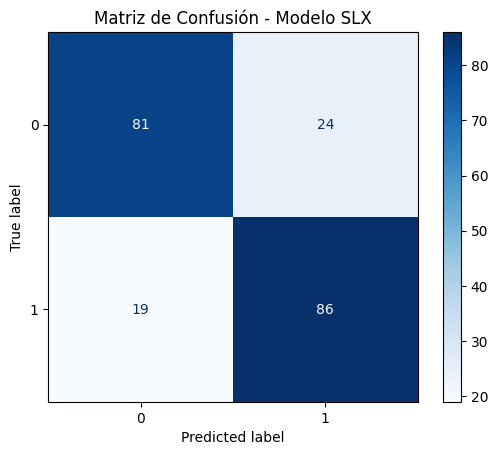

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones del modelo SLX
y_pred_slx = (ypr_s >= 0.5).astype(int)  # ypr_s son las probabilidades del modelo SLX

# Matriz de confusión
cm_slx = confusion_matrix(y_te_s, y_pred_slx)
print("Matriz de Confusión (SLX):\n", cm_slx)

# Visualización como gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm_slx, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Modelo SLX")
plt.show()


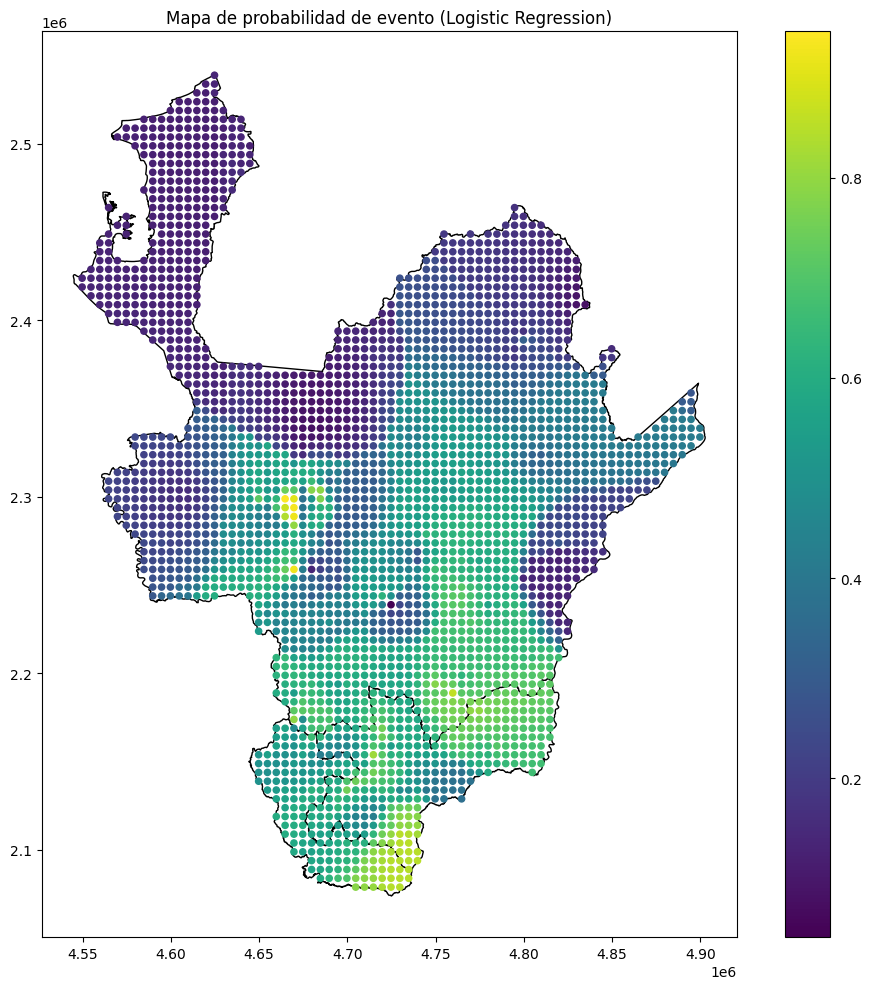

✔ Mapa de predicción exportado.


In [54]:
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# -----------------------------------
# 1) Crear una grilla sobre el polígono de departamentos
# -----------------------------------
gdf_dep = gpd.read_file(departamentos_path)
poly = gdf_dep.unary_union

# Resolución de la grilla (en unidades del CRS)
grid_res = 5000  # 5 km, ajusta según necesites

minx, miny, maxx, maxy = poly.bounds
xs = np.arange(minx, maxx, grid_res)
ys = np.arange(miny, maxy, grid_res)

grid_points = [Point(x, y) for x in xs for y in ys if poly.contains(Point(x, y))]
df_grid = gpd.GeoDataFrame(geometry=grid_points, crs=gdf_dep.crs)

# Extraer coordenadas
df_grid["X_proj"] = df_grid.geometry.x
df_grid["Y_proj"] = df_grid.geometry.y

# -----------------------------------
# 2) Asignar variables a la grilla
# -----------------------------------
# (Usamos IDW con k vecinos como para los negativos)
X_src_xy   = df_pos[["X_proj", "Y_proj"]].values
X_src_vals = df_pos[X_cols].values

from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=min(k_idw, len(df_pos)), algorithm="kd_tree").fit(X_src_xy)
dist, idx = nbrs.kneighbors(df_grid[["X_proj", "Y_proj"]].values)

dist = np.where(dist == 0, 1e-12, dist)
w = 1.0 / (dist ** p_idw)
w = w / w.sum(axis=1, keepdims=True)
X_grid_vals = np.einsum("ij,ijk->ik", w, X_src_vals[idx])

df_grid_vars = pd.DataFrame(X_grid_vals, columns=X_cols)
df_grid = pd.concat([df_grid.reset_index(drop=True), df_grid_vars], axis=1)

# -----------------------------------
# 3) Predecir con el modelo
# -----------------------------------
X_grid = df_grid[X_cols]
X_grid_imp = best_model.named_steps["imputer"].transform(X_grid)
X_grid_scaled = best_model.named_steps["scaler"].transform(X_grid_imp)
probs = best_model.named_steps["logreg"].predict_proba(X_grid_scaled)[:, 1]

df_grid["prob_evento"] = probs

# -----------------------------------
# 4) Graficar mapa de probabilidad
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 10))
gdf_dep.plot(ax=ax, color="white", edgecolor="black")
df_grid.plot(ax=ax, column="prob_evento", cmap="viridis", markersize=20, legend=True)
plt.title("Mapa de probabilidad de evento (Logistic Regression)")
plt.tight_layout()
plt.show()

# -----------------------------------
# 5) Exportar a CSV/GeoPackage (opcional)
# -----------------------------------
df_grid.to_file(out_dir / "prediccion_eventos.gpkg", layer="pred_grid", driver="GPKG")
df_grid[["X_proj", "Y_proj", "prob_evento"]].to_csv(out_dir / "prediccion_eventos.csv", index=False)
print("✔ Mapa de predicción exportado.")


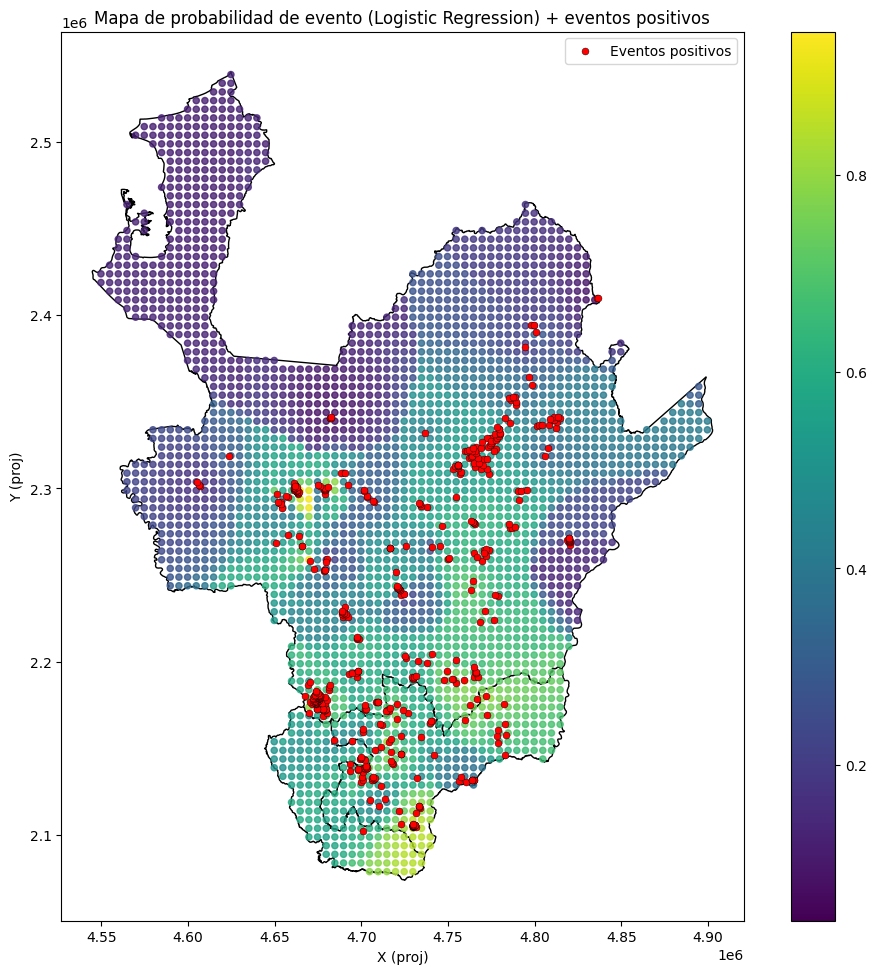

In [55]:
# -------------------------------
# 4) Graficar mapa de probabilidad + puntos positivos
# -------------------------------
# GeoDataFrame de la grilla (predicción)
gdf_grid = gpd.GeoDataFrame(
    df_grid,
    geometry=gpd.points_from_xy(df_grid["X_proj"], df_grid["Y_proj"]),
    crs=gdf_dep.crs
)

# GeoDataFrame de eventos positivos
gdf_pos_plot = gpd.GeoDataFrame(
    df_pos,
    geometry=gpd.points_from_xy(df_pos["X_proj"], df_pos["Y_proj"]),
    crs=gdf_dep.crs
)

fig, ax = plt.subplots(figsize=(10, 10))

# Polígonos
gdf_dep.plot(ax=ax, color="white", edgecolor="black")

# Grilla con probabilidades
gdf_grid.plot(
    ax=ax,
    column="prob_evento",
    cmap="viridis",
    markersize=20,
    legend=True,
    alpha=0.8
)

# Puntos positivos sobre el mapa
gdf_pos_plot.plot(
    ax=ax,
    color="red",
    markersize=25,
    label="Eventos positivos",
    edgecolor="black",
    linewidth=0.3
)

plt.legend()
plt.title("Mapa de probabilidad de evento (Logistic Regression) + eventos positivos")
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.tight_layout()
plt.show()


CRS departamentos: EPSG:9377
X/Y parecen estar en grados. Asumo EPSG:4326 y reproyecto a CRS de departamentos.
✔ Heatmap de correlación BASE guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\correlaciones_heatmap.png
Fitting 5 folds for each of 5 candidates, totalling 25 fits

========== MODELO BASE ==========
Mejores hiperparámetros (BASE): {'logreg__C': 1.0}
AUC-ROC (CV mejor modelo) BASE: 0.7446145124716553

--- MÉTRICAS EN TEST (BASE) ---
AUC-ROC: 0.8103401360544218

Classification report:
               precision    recall  f1-score   support

           0       0.76      0.71      0.74       105
           1       0.73      0.77      0.75       105

    accuracy                           0.74       210
   macro avg       0.74      0.74      0.74       210
weighted avg       0.74      0.74      0.74       210

Confusion matrix:
 [[75 30]
 [24 81]]
Precision: 0.730 | Recall: 0.771 | F1: 0.750

=== Top 20 coeficientes BASE (por |valor|) ===
             variable      coef  abs_coef  s

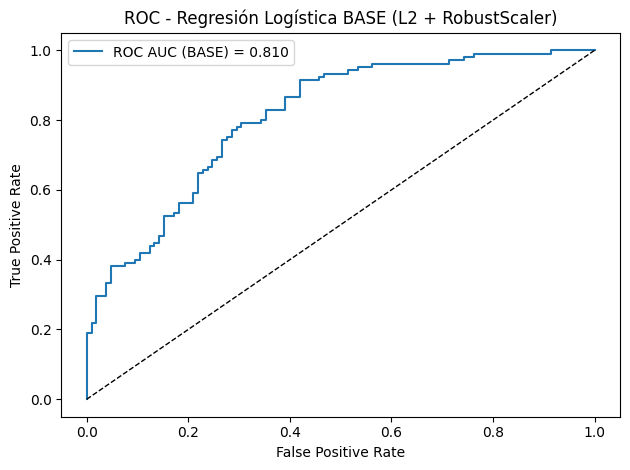

✔ Heatmap de correlación SLX guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\correlaciones_heatmap_slx.png
Fitting 5 folds for each of 5 candidates, totalling 25 fits

========== MODELO SLX ==========
Mejores hiperparámetros SLX: {'logreg__C': 0.1}
AUC-ROC (CV mejor modelo) SLX: 0.7824829931972788

--- MÉTRICAS EN TEST (SLX) ---
AUC-ROC: 0.8718367346938775

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79       105
           1       0.78      0.82      0.80       105

    accuracy                           0.80       210
   macro avg       0.80      0.80      0.80       210
weighted avg       0.80      0.80      0.80       210

Confusion matrix:
 [[81 24]
 [19 86]]
Precision: 0.782 | Recall: 0.819 | F1: 0.800

=== Top 20 coeficientes SLX (por |valor|) ===
                 variable      coef  abs_coef  signo
10         EdadMa_best_WX -0.660079  0.660079   -1.0
13      Bario_ppm_best_WX  0.489042  0.489042    1.0


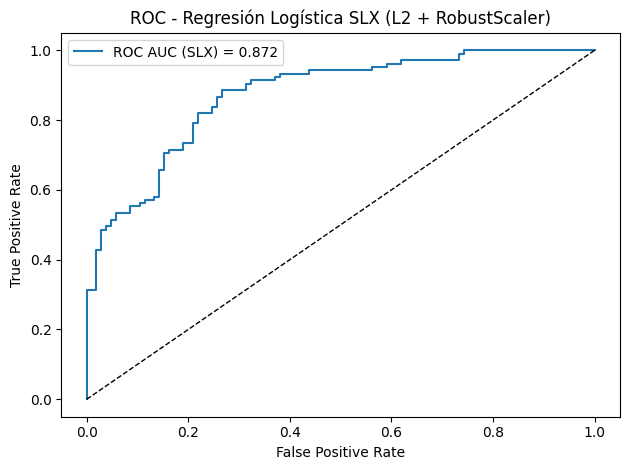


--- MORAN'S I (residuales TRAIN, SLX) ---
Moran's I: 0.399080
p-value (normalidad): 0.000000


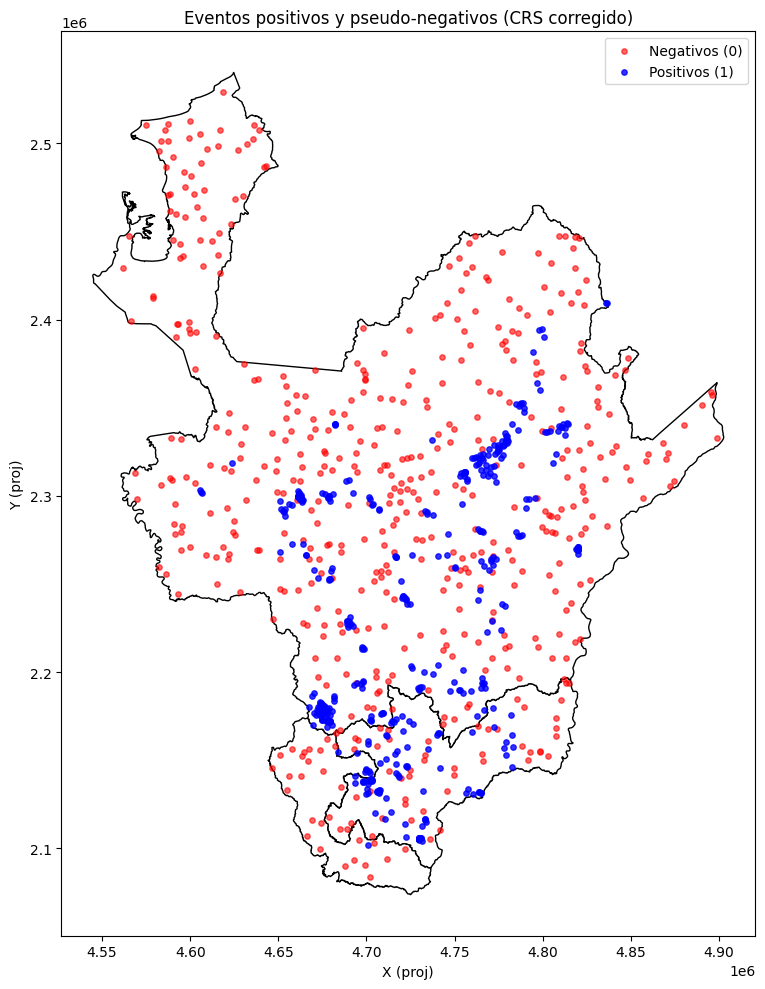

In [56]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix, precision_recall_fscore_support
)
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Nuevo ----
from libpysal.weights import KNN, WSP
from esda.moran import Moran
from scipy import sparse

# ===========================================================
# CONFIGURACIÓN
# ===========================================================
csv_path           = r"C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_enriquecidos.csv"
departamentos_path = r"C:\Git_SCA\AGE\departramentos_c"

out_dir            = Path(r"C:\Git_SCA\AGE\Codigo\salidas_fast")
out_dir.mkdir(parents=True, exist_ok=True)

out_coef_csv_base  = out_dir / "logreg_coeficientes_revisado.csv"
out_corr_png_base  = out_dir / "correlaciones_heatmap.png"

# salidas para el modelo SLX
out_coef_csv_slx   = out_dir / "logreg_slx_coeficientes.csv"
out_corr_png_slx   = out_dir / "correlaciones_heatmap_slx.png"

random_state       = 42

# Negativos
neg_ratio          = 1.0   # nº de negativos por cada positivo
k_idw              = 8     # k vecinos para IDW
p_idw              = 2     # potencia IDW

# Pesos espaciales (para SLX y Moran)
k_w                = 8     # nº de vecinos para la matriz de pesos KNN

# Columnas a excluir de los predictores
cols_drop          = ["X", "Y", "IG_LAT_W84", "IG_LON_W84", "label"]

# ===========================================================
# Helpers
# ===========================================================
def guess_points_crs(x, y):
    """Heurística simple: si luce como grados, asumimos EPSG:4326; si no, None."""
    if (np.nanmax(np.abs(x)) <= 180) and (np.nanmax(np.abs(y)) <= 90):
        return "EPSG:4326"
    return None

def plot_corr_heatmap(df_num, out_png, title="Matriz de correlación"):
    corr = df_num.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.iat[i,j]:.2f}", ha="center", va="center", fontsize=6)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlación (Pearson)")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# ===========================================================
# 1) Cargar positivos, crear label=1
# ===========================================================
df_pos = pd.read_csv(csv_path)
if not {"X", "Y"}.issubset(df_pos.columns):
    raise ValueError("El CSV debe tener columnas 'X' y 'Y' para generar negativos.")

df_pos["label"] = 1

# Variables numéricas candidatas
num_cols = df_pos.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in num_cols if c not in cols_drop]

# ===========================================================
# 2) CRS: leer departamentos y llevar puntos al mismo CRS
# ===========================================================
gdf_dep = gpd.read_file(departamentos_path)
crs_dep = gdf_dep.crs
print("CRS departamentos:", crs_dep)

# Intentamos inferir el CRS de tus X/Y
crs_guess = guess_points_crs(df_pos["X"].values, df_pos["Y"].values)
if crs_guess is None:
    print("Asumo que X/Y ya están en el CRS de departamentos.")
    gdf_pos = gpd.GeoDataFrame(df_pos, geometry=gpd.points_from_xy(df_pos["X"], df_pos["Y"]), crs=crs_dep)
else:
    print("X/Y parecen estar en grados. Asumo", crs_guess, "y reproyecto a CRS de departamentos.")
    gdf_pos_4326 = gpd.GeoDataFrame(df_pos, geometry=gpd.points_from_xy(df_pos["X"], df_pos["Y"]), crs=crs_guess)
    gdf_pos = gdf_pos_4326.to_crs(crs_dep)

# Reemplazamos X/Y por las coordenadas proyectadas
df_pos["X_proj"] = gdf_pos.geometry.x
df_pos["Y_proj"] = gdf_pos.geometry.y

# ===========================================================
# 3) Generar pseudo-negativos en TODO el departamento (CRS = dep)
# ===========================================================
poly = gdf_dep.unary_union
n_pos = len(df_pos)
n_neg = int(n_pos * neg_ratio)

minx, miny, maxx, maxy = poly.bounds
rng = np.random.default_rng(random_state)

xs, ys = [], []
while len(xs) < n_neg:
    xr = rng.uniform(minx, maxx)
    yr = rng.uniform(miny, maxy)
    if poly.contains(Point(xr, yr)):
        xs.append(xr)
        ys.append(yr)

df_neg_xy = pd.DataFrame({"X_proj": xs, "Y_proj": ys})

# ===========================================================
# 4) Imputar variables a negativos vía IDW kNN
# ===========================================================
X_src_xy   = df_pos[["X_proj", "Y_proj"]].values
X_src_vals = df_pos[X_cols].values

nbrs = NearestNeighbors(n_neighbors=min(k_idw, len(df_pos)), algorithm="kd_tree").fit(X_src_xy)
dist, idx = nbrs.kneighbors(df_neg_xy[["X_proj", "Y_proj"]].values)

dist = np.where(dist == 0, 1e-12, dist)
w_idw = 1.0 / (dist ** p_idw)
w_idw = w_idw / w_idw.sum(axis=1, keepdims=True)

X_neg_vals = np.einsum("ij,ijk->ik", w_idw, X_src_vals[idx])

df_neg = pd.DataFrame(X_neg_vals, columns=X_cols)
df_neg["X_proj"] = df_neg_xy["X_proj"].values
df_neg["Y_proj"] = df_neg_xy["Y_proj"].values
df_neg["label"] = 0

# ===========================================================
# 5) Dataset final para modelar (BASE)
# ===========================================================
df_all = pd.concat(
    [df_pos[["label", "X_proj", "Y_proj"] + X_cols],
     df_neg[["label", "X_proj", "Y_proj"] + X_cols]],
    ignore_index=True
)

# -----------------------------------------------------------
# 5.1) Modelo BASE (sin efectos espaciales)
# -----------------------------------------------------------
X_base = df_all[X_cols]
y_all  = df_all["label"].astype(int)

# 6) Heatmap de correlación (base)
plot_corr_heatmap(X_base, out_corr_png_base, title="Matriz de correlación (BASE)")
print(f"✔ Heatmap de correlación BASE guardado en: {out_corr_png_base}")

# 7) Train/Test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_all, test_size=0.2, stratify=y_all, random_state=random_state
)

# 8) Pipeline BASE
pipe_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",  # solo L2
        penalty="l2"
    ))
])

param_grid = {
    "logreg__C": [1e-4, 1e-3, 1e-2, 0.1, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

gs_base = GridSearchCV(
    pipe_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs_base.fit(X_train_b, y_train_b)

print("\n========== MODELO BASE ==========")
print("Mejores hiperparámetros (BASE):", gs_base.best_params_)
print("AUC-ROC (CV mejor modelo) BASE:", gs_base.best_score_)

best_model_base = gs_base.best_estimator_
y_proba_b = best_model_base.predict_proba(X_test_b)[:, 1]
y_pred_b  = (y_proba_b >= 0.5).astype(int)

print("\n--- MÉTRICAS EN TEST (BASE) ---")
print("AUC-ROC:", roc_auc_score(y_test_b, y_proba_b))
print("\nClassification report:\n", classification_report(y_test_b, y_pred_b))
print("Confusion matrix:\n", confusion_matrix(y_test_b, y_pred_b))

prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(y_test_b, y_pred_b, average="binary")
print(f"Precision: {prec_b:.3f} | Recall: {rec_b:.3f} | F1: {f1_b:.3f}")

# 10) Coeficientes BASE ordenados
coefs_b = best_model_base.named_steps["logreg"].coef_.ravel()
feat_importance_b = (
    pd.DataFrame({
        "variable": X_base.columns,
        "coef": coefs_b,
        "abs_coef": np.abs(coefs_b),
        "signo": np.sign(coefs_b)
    })
    .sort_values("abs_coef", ascending=False)
)
feat_importance_b.to_csv(out_coef_csv_base, index=False)
print("\n=== Top 20 coeficientes BASE (por |valor|) ===")
print(feat_importance_b.head(20))
print(f"\n✔ Coeficientes BASE guardados en: {out_coef_csv_base}")

# 11) Curva ROC BASE
fpr_b, tpr_b, thr_b = roc_curve(y_test_b, y_proba_b)
plt.figure()
plt.plot(fpr_b, tpr_b, label=f"ROC AUC (BASE) = {roc_auc_score(y_test_b, y_proba_b):.3f}")
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Regresión Logística BASE (L2 + RobustScaler)")
plt.legend()
plt.tight_layout()
plt.show()

# ===========================================================
# 12) MODELO SLX-LOGIT (WX)
# ===========================================================

# 12.1) Matriz de pesos KNN (sobre TODO el dataset para SLX)
coords_all = df_all[["X_proj", "Y_proj"]].values
w_knn = KNN.from_array(coords_all, k=k_w)
w_knn.transform = "r"   # estandarización por filas
W_sparse = w_knn.sparse.tocsr()

# 12.2) Construir WX y concatenar
X_base_np = df_all[X_cols].to_numpy()
WX = W_sparse.dot(X_base_np)
WX_cols = [f"{c}_WX" for c in X_cols]

df_WX = pd.DataFrame(WX, columns=WX_cols)
X_slx_df = pd.concat([df_all[X_cols].reset_index(drop=True), df_WX], axis=1)

# (opcional) Heatmap de correlación SLX
plot_corr_heatmap(X_slx_df, out_corr_png_slx, title="Matriz de correlación (SLX)")
print(f"✔ Heatmap de correlación SLX guardado en: {out_corr_png_slx}")

# Reemplazamos X e y para el modelo SLX
X_slx = X_slx_df
y_slx = y_all

X_train, X_test, y_train, y_test = train_test_split(
    X_slx, y_slx, test_size=0.2, stratify=y_slx, random_state=random_state
)

# 12.3) Pipeline SLX (idéntico, solo cambian features)
pipe_slx = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        penalty="l2"
    ))
])

param_grid_slx = {"logreg__C": [1e-4, 1e-3, 1e-2, 0.1, 1.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

gs_slx = GridSearchCV(
    pipe_slx,
    param_grid=param_grid_slx,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs_slx.fit(X_train, y_train)

print("\n========== MODELO SLX ==========")
print("Mejores hiperparámetros SLX:", gs_slx.best_params_)
print("AUC-ROC (CV mejor modelo) SLX:", gs_slx.best_score_)

best_model_slx = gs_slx.best_estimator_
y_proba = best_model_slx.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

print("\n--- MÉTRICAS EN TEST (SLX) ---")
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

# 12.4) Coeficientes SLX ordenados
coefs_slx = best_model_slx.named_steps["logreg"].coef_.ravel()
feat_importance_slx = (
    pd.DataFrame({
        "variable": X_slx.columns,
        "coef": coefs_slx,
        "abs_coef": np.abs(coefs_slx),
        "signo": np.sign(coefs_slx)
    })
    .sort_values("abs_coef", ascending=False)
)
feat_importance_slx.to_csv(out_coef_csv_slx, index=False)
print("\n=== Top 20 coeficientes SLX (por |valor|) ===")
print(feat_importance_slx.head(20))
print(f"\n✔ Coeficientes SLX guardados en: {out_coef_csv_slx}")

# 12.5) Curva ROC SLX
fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC (SLX) = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Regresión Logística SLX (L2 + RobustScaler)")
plt.legend()
plt.tight_layout()
plt.show()

# 12.6) Moran's I de residuales (TRAIN) para verificar autocorrelación restante
yhat_train = best_model_slx.predict_proba(X_train)[:, 1]
resid_train = y_train.values - yhat_train

# extraemos la submatriz W correspondiente a los índices de train
train_idx = X_train.index.values
W_train = W_sparse[train_idx, :][:, train_idx]

# reconstruimos un objeto weights para Moran
w_train = WSP(W_train).to_W()

mi = Moran(resid_train, w_train, two_tailed=False)
print("\n--- MORAN'S I (residuales TRAIN, SLX) ---")
print(f"Moran's I: {mi.I:.6f}")
print(f"p-value (normalidad): {mi.p_norm:.6f}")

# ===========================================================
# 13) Mapa (CRS corregido) – opcional, igual a tu bloque original
# ===========================================================
gdf_all = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all["X_proj"], df_all["Y_proj"]),
    crs=crs_dep
)

gdf_pos_plot = gdf_all[gdf_all["label"] == 1]
gdf_neg_plot = gdf_all[gdf_all["label"] == 0]

fig, ax = plt.subplots(figsize=(10, 10))
gdf_dep.plot(ax=ax, color="white", edgecolor="black")
gdf_neg_plot.plot(ax=ax, color="red", markersize=15, label="Negativos (0)", alpha=0.6)
gdf_pos_plot.plot(ax=ax, color="blue", markersize=15, label="Positivos (1)", alpha=0.8)

plt.legend()
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.title("Eventos positivos y pseudo-negativos (CRS corregido)")
plt.tight_layout()
plt.show()


In [64]:
import numdifftools as nd
from scipy.stats import norm
from scipy.special import expit

def loglik_pseudologit(beta, rho, X, y, W):
    """Log-(pseudo)verosimilitud Bernoulli del SAR-logit con Wy observado."""
    Wy = W.dot(y)
    eta = X @ beta + rho * Wy
    p = expit(eta)
    eps = 1e-12
    return np.sum(y * np.log(np.clip(p, eps, 1 - eps)) + (1 - y) * np.log(np.clip(1 - p, eps, 1 - eps)))

def loglik_null(y):
    """Log-verosimilitud del modelo nulo (solo intercepto) para binaria."""
    p = y.mean()
    eps = 1e-12
    return np.sum(y * np.log(np.clip(p, eps, 1 - eps)) + (1 - y) * np.log(np.clip(1 - p, eps, 1 - eps)))

def pseudo_r2s(ll_model, ll_null, y, p_hat, k):
    """Devuelve varios pseudo-R²."""
    n = len(y)
    Lm = np.exp(ll_model)
    L0 = np.exp(ll_null)

    r2_mcf = 1 - (ll_model / ll_null)
    r2_mcf_adj = 1 - (ll_model - k) / (ll_null)

    r2_cs = 1 - (L0 / Lm) ** (2.0 / n)
    r2_nag = r2_cs / (1 - (L0) ** (2.0 / n))

    r2_tjur = p_hat[y == 1].mean() - p_hat[y == 0].mean()

    y_bar = y.mean()
    r2_efron = 1 - np.sum((y - p_hat) ** 2) / np.sum((y - y_bar) ** 2)

    return {
        "McFadden": r2_mcf,
        "McFadden_adj": r2_mcf_adj,
        "Cox_Snell": r2_cs,
        "Nagelkerke": r2_nag,
        "Tjur": r2_tjur,
        "Efron": r2_efron
    }

# ------------ Hessiana numérica en TRAIN ------------
# Usamos la misma parte de train que usaste para optimizar:
W_train_sp = W_sparse[idx_train, :][:, idx_train]

def nll_wrap(params):
    # función objetivo (neg log pseudolikelihood) que usaste para optimizar
    return neg_log_pseudolik(params, X_train, y_train, W_train_sp, l2=0.0)

# Hessiana numérica de la neg-log-pseudolikelihood
H = nd.Hessian(nll_wrap)(params_hat)

# Var-Cov aproximada = inversa de la Hessiana
# (para pseudoverosimilitud esto es el análogo de Godambe simplificado;
#  para algo más riguroso puedes montar sandwich o bootstrap por bloques espaciales)
cov = np.linalg.inv(H)

# Errores estándar
se = np.sqrt(np.diag(cov))

# Extraemos por comodidad
k_beta = len(beta_hat)
se_beta = se[:k_beta]
se_rho  = se[k_beta]

z_beta = beta_hat / se_beta
p_beta = 2 * (1 - norm.cdf(np.abs(z_beta)))

z_rho  = rho_hat / se_rho
p_rho  = 2 * (1 - norm.cdf(np.abs(z_rho)))

# DataFrame de coeficientes
coef_report = pd.DataFrame({
    "variable": feature_names + ["rho"],
    "beta": np.r_[beta_hat, rho_hat],
    "std_error": np.r_[se_beta, se_rho],
    "z": np.r_[z_beta, z_rho],
    "p_value": np.r_[p_beta, p_rho],
    "sign": np.sign(np.r_[beta_hat, rho_hat])
}).sort_values("p_value")

print("\n=========== COEFICIENTES + p-valores (SAR-logit) ===========")
print(coef_report.to_string(index=False))

# Guardar a CSV
coef_report_csv = out_dir / "sar_logit_coeficientes_pvalues.csv"
coef_report.to_csv(coef_report_csv, index=False)
print(f"\n✔ Coeficientes con p-valores guardados en: {coef_report_csv}")




=========== COEFICIENTES + p-valores (SAR-logit) ===========
          variable      beta  std_error         z      p_value  sign
       EdadMa_best -1.001012   0.137041 -7.304484 2.784439e-13  -1.0
               rho  0.868391   0.169337  5.128185 2.925490e-07   1.0
    Bario_ppm_best  0.450889   0.107065  4.211365 2.538321e-05   1.0
       Moho_Z_best  0.407932   0.106950  3.814244 1.366007e-04   1.0
  Bismuto_ppm_best  0.157986   0.049982  3.160842 1.573138e-03   1.0
    Cromo_ppm_best  0.159298   0.058756  2.711200 6.704014e-03   1.0
Antimonio_ppm_best -0.048193   0.025830 -1.865765 6.207421e-02  -1.0
 Mercurio_ppm_best  0.033844   0.025503  1.327045 1.844939e-01   1.0
        Moho_Z_var -0.113212   0.093197 -1.214763 2.244564e-01  -1.0
   Azufre_ppm_best -0.005880   0.030397 -0.193453 8.466044e-01  -1.0
    Plata_ppm_best -0.003658        NaN       NaN          NaN  -1.0

✔ Coeficientes con p-valores guardados en: C:\Git_SCA\AGE\Codigo\salidas_fast\sar_logit_coeficientes_pvalues.

✔ Mapa de predicción SLX guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\prediccion_SLX.tif


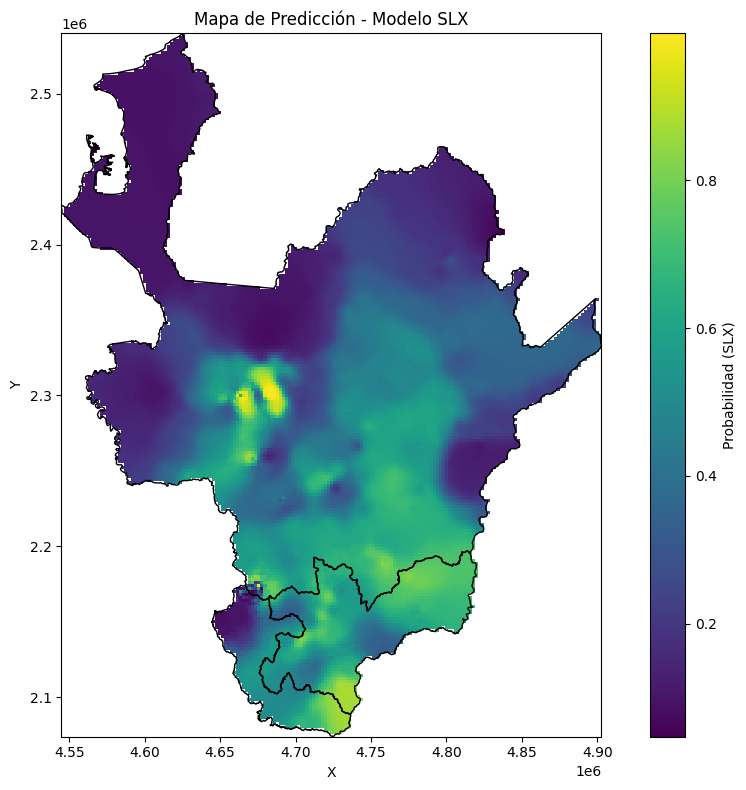

In [95]:
# ===========================================================
# MAPA DE PREDICCIÓN (MODELO SLX) — ROBUSTO
# ===========================================================
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from sklearn.neighbors import NearestNeighbors
from libpysal.weights import KNN

# ---------------------------
# 0) Parámetros
# ---------------------------
res = 2000         # tamaño del pixel (ajústalo a tu escala)
k_pred = min(k_w, 8)  # nº vecinos para W en la malla (puedes usar el mismo k_w)

# ---------------------------
# 1) Malla regular dentro del/de los departamentos
# ---------------------------
gdf_dep_proj = gdf_dep.to_crs(crs_dep)
minx, miny, maxx, maxy = gdf_dep_proj.total_bounds

xs = np.arange(minx, maxx, res)
ys = np.arange(miny, maxy, res)
xx, yy = np.meshgrid(xs, ys)

grid_points = np.c_[xx.ravel(), yy.ravel()]
gdf_grid = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(grid_points[:, 0], grid_points[:, 1]),
    crs=crs_dep
)

# Solo puntos dentro del polígono
mask_inside = gdf_grid.within(gdf_dep_proj.unary_union)
gdf_grid = gdf_grid.loc[mask_inside].reset_index(drop=True)

# ---------------------------
# 2) Interpolar (IDW) las variables X_cols a la malla
# ---------------------------
X_src_xy   = df_all[["X_proj", "Y_proj"]].values
X_src_vals = df_all[X_cols].values

nbrs_grid = NearestNeighbors(
    n_neighbors=min(k_idw, len(df_all)),
    algorithm="kd_tree"
).fit(X_src_xy)

dist_grid, idx_grid = nbrs_grid.kneighbors(
    np.c_[gdf_grid.geometry.x.values, gdf_grid.geometry.y.values]
)

dist_grid = np.where(dist_grid == 0, 1e-12, dist_grid)
w_grid = 1.0 / (dist_grid ** p_idw)
w_grid /= w_grid.sum(axis=1, keepdims=True)

X_grid_vals = np.einsum("ij,ijk->ik", w_grid, X_src_vals[idx_grid])

df_grid_vars = pd.DataFrame(X_grid_vals, columns=X_cols)
df_grid_vars["X_proj"] = gdf_grid.geometry.x.values
df_grid_vars["Y_proj"] = gdf_grid.geometry.y.values

# ---------------------------
# 3) Construir WX para el SLX (sobre la malla)
# ---------------------------
coords_grid = df_grid_vars[["X_proj", "Y_proj"]].to_numpy()

# Filtrar filas con NaN/Inf en coords o en las X
valid_mask_coords = np.isfinite(coords_grid).all(axis=1)
valid_mask_x = np.isfinite(df_grid_vars[X_cols].to_numpy()).all(axis=1)
valid_mask = valid_mask_coords & valid_mask_x

df_grid_vars_valid = df_grid_vars.loc[valid_mask].reset_index(drop=True)
coords_grid_valid = df_grid_vars_valid[["X_proj", "Y_proj"]].to_numpy()

# Si tras filtrar hay muy pocos puntos, abortamos
if len(df_grid_vars_valid) <= k_pred:
    raise ValueError("No hay suficientes puntos válidos en la malla para construir KNN.")

w_knn_grid = KNN.from_array(coords_grid_valid, k=k_pred)
w_knn_grid.transform = "r"
W_grid = w_knn_grid.sparse.tocsr()

WX_grid = W_grid.dot(df_grid_vars_valid[X_cols].values)
WX_cols = [f"{c}_WX" for c in X_cols]
df_WX_grid = pd.DataFrame(WX_grid, columns=WX_cols, index=df_grid_vars_valid.index)

# ---------------------------
# 4) Armar el DataFrame de predicción con el MISMO orden de columnas que el modelo SLX
# ---------------------------
# Columnas que usó el modelo SLX
slx_feature_order = list(X_slx.columns)

X_slx_grid_full = pd.concat(
    [df_grid_vars_valid[X_cols].reset_index(drop=True), df_WX_grid.reset_index(drop=True)],
    axis=1
)
# Reordenar para que coincida con el entrenamiento
X_slx_grid_full = X_slx_grid_full.reindex(columns=slx_feature_order)

# ---------------------------
# 5) Transformar con el pipeline y predecir
# ---------------------------
X_slx_grid_imp = best_s.named_steps["imp"].transform(X_slx_grid_full)
X_slx_grid_scaled = best_s.named_steps["sc"].transform(X_slx_grid_imp)
y_pred_grid = best_s.named_steps["lr"].predict_proba(X_slx_grid_scaled)[:, 1]

# ---------------------------
# 6) Volcar predicciones a raster
# ---------------------------
z_grid = np.full(xx.shape, np.nan, dtype="float32")

# Creamos un vector de índices para el grid original filtrado (validos + inside)
# Para pintar: necesitamos mapear cada punto válido a la celda del raster
x_to_col = lambda x: int((x - minx) / res)
y_to_row = lambda y: int((maxy - y) / res)  # origin='upper'

xs_valid = df_grid_vars_valid["X_proj"].values
ys_valid = df_grid_vars_valid["Y_proj"].values

for val, xg, yg in zip(y_pred_grid, xs_valid, ys_valid):
    col = x_to_col(xg)
    row = y_to_row(yg)
    if 0 <= row < z_grid.shape[0] and 0 <= col < z_grid.shape[1]:
        z_grid[row, col] = val

transform = from_origin(minx, maxy, res, res)
raster_path = out_dir / "prediccion_SLX.tif"

with rasterio.open(
    raster_path,
    "w",
    driver="GTiff",
    height=z_grid.shape[0],
    width=z_grid.shape[1],
    count=1,
    dtype="float32",
    crs=crs_dep,
    transform=transform,
    nodata=np.nan
) as dst:
    dst.write(z_grid, 1)

print(f"✔ Mapa de predicción SLX guardado en: {raster_path}")

# ---------------------------
# 7) Visualización (no invertido)
# ---------------------------
plt.figure(figsize=(10, 8))
plt.imshow(
    z_grid,
    extent=(minx, maxx, miny, maxy),
    origin='upper',                 # mantenemos coherencia con y_to_row
    cmap="viridis"
)
gdf_dep_proj.boundary.plot(ax=plt.gca(), color="black", linewidth=1)
plt.colorbar(label="Probabilidad (SLX)")
plt.title("Mapa de Predicción - Modelo SLX")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()


SAR

CRS departamentos: EPSG:9377
X/Y parecen estar en grados. Asumo EPSG:4326 y reproyecto a CRS de departamentos.
✔ Heatmap de correlación guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\correlaciones_heatmap_SAR.png

===== RESULTADOS SAR-LOGIT (Pseudoverosimilitud) =====
rho_hat: 0.8684
             variable      beta
0         EdadMa_best -1.001012
3      Bario_ppm_best  0.450889
1         Moho_Z_best  0.407932
5      Cromo_ppm_best  0.159298
7    Bismuto_ppm_best  0.157986
2          Moho_Z_var -0.113212
9  Antimonio_ppm_best -0.048193
8   Mercurio_ppm_best  0.033844
4     Azufre_ppm_best -0.005880
6      Plata_ppm_best -0.003658

--- MÉTRICAS EN TEST (SAR-LOGIT) ---
AUC-ROC: 0.814512
Accuracy: 0.728571
Precision: 0.703390 | Recall: 0.790476 | F1: 0.744395

Classification report:
               precision    recall  f1-score   support

           0       0.76      0.67      0.71       105
           1       0.70      0.79      0.74       105

    accuracy                           0.73 

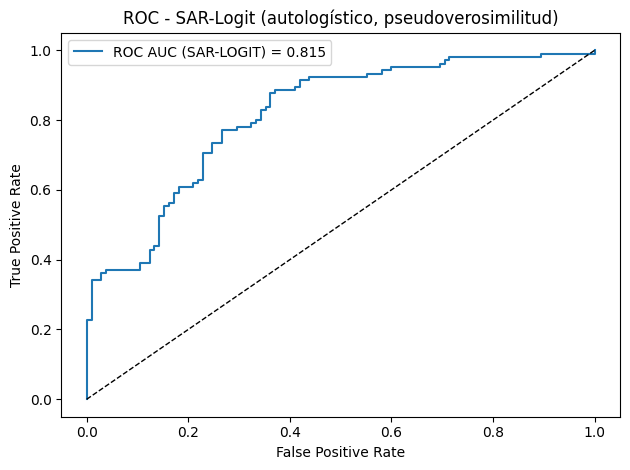


=== Pseudo-R² (SAR-Logit - TEST) ===
   Pseudo-R2 / LL       Valor
         McFadden    0.229497
McFadden_ajustado    0.153928
        Cox_Snell    0.272507
       Nagelkerke    0.363343
             Tjur    0.266488
            Efron    0.296852
    LogLik_Modelo -112.155047
      LogLik_Nulo -145.560908

--- MORAN'S I Residuales (TRAIN) ---
Moran's I: 0.424946
p-value (normalidad): 0.000000


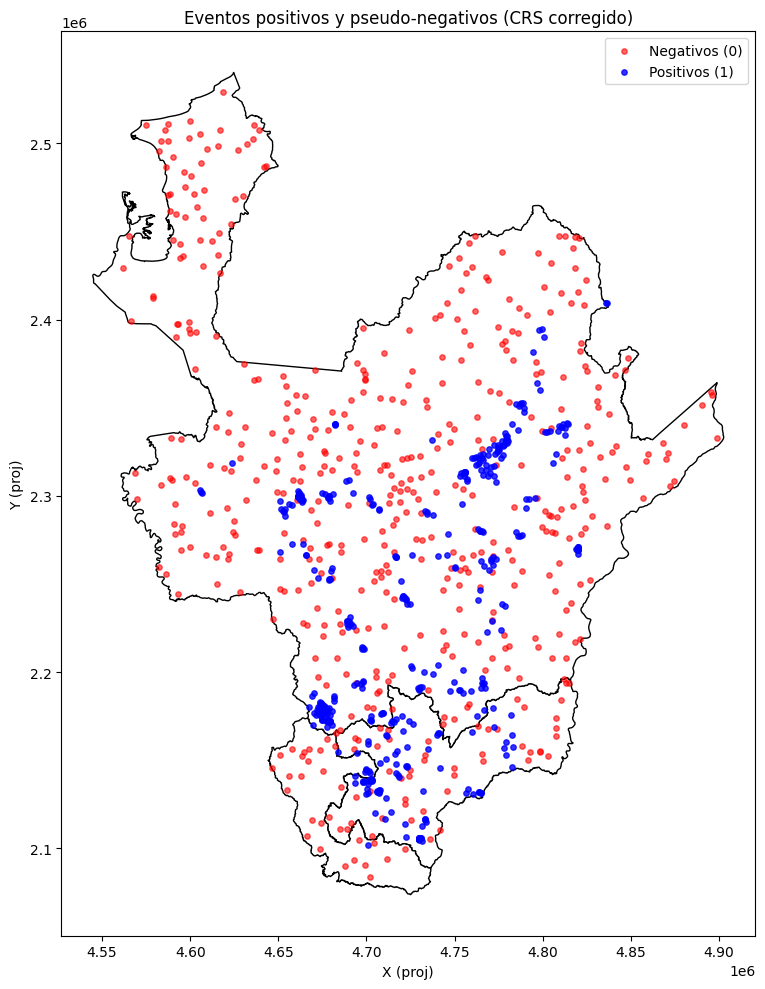

In [90]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)

from libpysal.weights import KNN, WSP
from esda.moran import Moran
from scipy.optimize import minimize
from scipy.special import expit

# ===========================================================
# CONFIGURACIÓN
# ===========================================================
csv_path           = r"C:\Git_SCA\AGE\Codigo\salidas_fast\eventos_enriquecidos.csv"
departamentos_path = r"C:\Git_SCA\AGE\departramentos_c"

out_dir            = Path(r"C:\Git_SCA\AGE\Codigo\salidas_fast")
out_dir.mkdir(parents=True, exist_ok=True)

out_corr_png       = out_dir / "correlaciones_heatmap_SAR.png"
random_state       = 42

# Negativos
neg_ratio          = 1.0   # nº de negativos por cada positivo
k_idw              = 8     # k vecinos para IDW
p_idw              = 2     # potencia IDW

# Matriz de pesos (para SAR)
k_w                = 8     # vecinos en W (ajusta según tu escala)
rho_bounds         = (-0.99, 0.99)

# Columnas a excluir de los predictores
cols_drop          = ["X", "Y", "IG_LAT_W84", "IG_LON_W84", "label"]

# ===========================================================
# Helpers
# ===========================================================
def guess_points_crs(x, y):
    if (np.nanmax(np.abs(x)) <= 180) and (np.nanmax(np.abs(y)) <= 90):
        return "EPSG:4326"
    return None

def plot_corr_heatmap(df_num, out_png, title="Matriz de correlación"):
    corr = df_num.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.iat[i,j]:.2f}", ha="center", va="center", fontsize=6)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlación (Pearson)")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def fixed_point_probs(X, W, beta, rho, tol=1e-6, max_iter=500):
    """
    Resuelve p = sigmoid(X beta + rho W p) por iteración de punto fijo.
    """
    p = expit(X @ beta)  # inicialización
    for _ in range(max_iter):
        p_new = expit(X @ beta + rho * W.dot(p))
        if np.max(np.abs(p_new - p)) < tol:
            return p_new
        p = p_new
    return p

def neg_log_pseudolik(params, X, y, W, l2=0.0):
    """
    Pseudoverosimilitud autologística (Besag):
    L_ps = prod Bernoulli(y_i | logit^{-1}(x_i'beta + rho * (Wy)_i))
    """
    beta = params[:-1]
    rho  = params[-1]
    if not (rho_bounds[0] < rho < rho_bounds[1]):
        return np.inf

    Wy = W.dot(y)  # rezago espacial de la respuesta observada
    eta = X @ beta + rho * Wy
    p = expit(eta)

    eps = 1e-12
    ll = y * np.log(np.clip(p, eps, 1 - eps)) + (1 - y) * np.log(np.clip(1 - p, eps, 1 - eps))
    penalty = 0.5 * l2 * np.sum(beta**2)
    return -np.sum(ll) + penalty

def pseudo_r2_binario(y, p_hat, k_params):
    """ Calcula varios pseudo-R² y log-likelihoods para modelos binarios. """
    eps = 1e-12
    p_hat = np.clip(p_hat, eps, 1 - eps)
    ll_model = np.sum(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))

    p_null = np.repeat(y.mean(), len(y))
    ll_null = np.sum(y * np.log(p_null) + (1 - y) * np.log(1 - p_null))

    # McFadden
    r2_mcf = 1 - (ll_model / ll_null)
    r2_mcf_adj = 1 - (ll_model - k_params) / ll_null

    # Cox & Snell y Nagelkerke
    Lm = np.exp(ll_model)
    L0 = np.exp(ll_null)
    n = len(y)
    r2_cs  = 1 - (L0 / Lm) ** (2.0 / n)
    r2_nag = r2_cs / (1 - (L0) ** (2.0 / n))

    # Tjur
    r2_tjur = p_hat[y == 1].mean() - p_hat[y == 0].mean()

    # Efron
    y_bar = y.mean()
    r2_efron = 1 - np.sum((y - p_hat)**2) / np.sum((y - y_bar)**2)

    return {
        "McFadden": r2_mcf,
        "McFadden_ajustado": r2_mcf_adj,
        "Cox_Snell": r2_cs,
        "Nagelkerke": r2_nag,
        "Tjur": r2_tjur,
        "Efron": r2_efron,
        "LogLik_Modelo": ll_model,
        "LogLik_Nulo": ll_null
    }

# ===========================================================
# 1) Cargar positivos, crear label=1
# ===========================================================
df_pos = pd.read_csv(csv_path)
if not {"X", "Y"}.issubset(df_pos.columns):
    raise ValueError("El CSV debe tener columnas 'X' y 'Y' para generar negativos.")

df_pos["label"] = 1

num_cols = df_pos.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in num_cols if c not in cols_drop]

# ===========================================================
# 2) CRS y reproyección
# ===========================================================
gdf_dep = gpd.read_file(departamentos_path)
crs_dep = gdf_dep.crs
print("CRS departamentos:", crs_dep)

crs_guess = guess_points_crs(df_pos["X"].values, df_pos["Y"].values)
if crs_guess is None:
    print("Asumo que X/Y ya están en el CRS de departamentos.")
    gdf_pos = gpd.GeoDataFrame(df_pos, geometry=gpd.points_from_xy(df_pos["X"], df_pos["Y"]), crs=crs_dep)
else:
    print("X/Y parecen estar en grados. Asumo", crs_guess, "y reproyecto a CRS de departamentos.")
    gdf_pos_4326 = gpd.GeoDataFrame(df_pos, geometry=gpd.points_from_xy(df_pos["X"], df_pos["Y"]), crs=crs_guess)
    gdf_pos = gdf_pos_4326.to_crs(crs_dep)

df_pos["X_proj"] = gdf_pos.geometry.x
df_pos["Y_proj"] = gdf_pos.geometry.y

# ===========================================================
# 3) Pseudo-negativos
# ===========================================================
poly = gdf_dep.unary_union
n_pos = len(df_pos)
n_neg = int(n_pos * neg_ratio)

minx, miny, maxx, maxy = poly.bounds
rng = np.random.default_rng(random_state)

xs, ys = [], []
while len(xs) < n_neg:
    xr = rng.uniform(minx, maxx)
    yr = rng.uniform(miny, maxy)
    if poly.contains(Point(xr, yr)):
        xs.append(xr)
        ys.append(yr)

df_neg_xy = pd.DataFrame({"X_proj": xs, "Y_proj": ys})

# ===========================================================
# 4) Imputación de features a negativos por IDW kNN
# ===========================================================
X_src_xy   = df_pos[["X_proj", "Y_proj"]].values
X_src_vals = df_pos[X_cols].values

nbrs = NearestNeighbors(n_neighbors=min(k_idw, len(df_pos)), algorithm="kd_tree").fit(X_src_xy)
dist, idx = nbrs.kneighbors(df_neg_xy[["X_proj", "Y_proj"]].values)

dist = np.where(dist == 0, 1e-12, dist)
w_idw = 1.0 / (dist ** p_idw)
w_idw = w_idw / w_idw.sum(axis=1, keepdims=True)

X_neg_vals = np.einsum("ij,ijk->ik", w_idw, X_src_vals[idx])

df_neg = pd.DataFrame(X_neg_vals, columns=X_cols)
df_neg["X_proj"] = df_neg_xy["X_proj"].values
df_neg["Y_proj"] = df_neg_xy["Y_proj"].values
df_neg["label"]  = 0

# ===========================================================
# 5) Dataset final
# ===========================================================
df_all = pd.concat(
    [df_pos[["label", "X_proj", "Y_proj"] + X_cols],
     df_neg[["label", "X_proj", "Y_proj"] + X_cols]],
    ignore_index=True
)

y_all = df_all["label"].astype(int).values
coords = df_all[["X_proj", "Y_proj"]].values
X_raw  = df_all[X_cols].copy()

# ===========================================================
# 6) Preprocesamiento (imputación + escalado robusto)
# ===========================================================
imp = SimpleImputer(strategy="median")
scaler = RobustScaler()

X_imp = imp.fit_transform(X_raw)
X_std = scaler.fit_transform(X_imp)

feature_names = X_cols

plot_corr_heatmap(pd.DataFrame(X_std, columns=feature_names), out_corr_png,
                  title="Matriz de correlación (features preprocesadas)")
print(f"✔ Heatmap de correlación guardado en: {out_corr_png}")

# ===========================================================
# 7) Train/Test split
# ===========================================================
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_std, y_all, np.arange(len(y_all)),
    test_size=0.2, stratify=y_all, random_state=random_state
)

# ===========================================================
# 8) Matriz de pesos W (KNN) sobre TODO el dataset
# ===========================================================
w_knn = KNN.from_array(coords, k=k_w)
w_knn.transform = "r"  # estandarización por filas
W_sparse = w_knn.sparse.tocsr()

# Submatriz de train para el chequeo de Moran
W_train = W_sparse[idx_train, :][:, idx_train]
w_train = WSP(W_train).to_W()

# ===========================================================
# 9) Estimación SAR-logit (autologístico) por pseudoverosimilitud
# ===========================================================
p, q = X_train.shape
init_beta = np.zeros(q)
init_rho  = 0.0
init_params = np.r_[init_beta, init_rho]

def obj_fun(params):
    return neg_log_pseudolik(params, X_train, y_train, W_sparse[idx_train, :][:, idx_train], l2=0.0)

bounds = [(-np.inf, np.inf)] * q + [rho_bounds]
res = minimize(
    obj_fun,
    init_params,
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 1000, "disp": True}
)

if not res.success:
    print("⚠ Optimización no convergió:", res.message)

params_hat = res.x
beta_hat = params_hat[:-1]
rho_hat  = params_hat[-1]

print("\n===== RESULTADOS SAR-LOGIT (Pseudoverosimilitud) =====")
print(f"rho_hat: {rho_hat:.4f}")
coef_df = pd.DataFrame({"variable": feature_names, "beta": beta_hat})
coef_df = coef_df.sort_values("beta", key=np.abs, ascending=False)
print(coef_df.head(20))

# ===========================================================
# 10) Predicción en TEST (punto fijo)
# ===========================================================
W_test = W_sparse[idx_test, :][:, idx_test]
p_test = fixed_point_probs(X_test, W_test, beta_hat, rho_hat, tol=1e-6, max_iter=1000)
y_pred_test = (p_test >= 0.5).astype(int)

print("\n--- MÉTRICAS EN TEST (SAR-LOGIT) ---")
auc = roc_auc_score(y_test, p_test)
acc = accuracy_score(y_test, y_pred_test)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, average="binary")
cm = confusion_matrix(y_test, y_pred_test)

print(f"AUC-ROC: {auc:.6f}")
print(f"Accuracy: {acc:.6f}")
print(f"Precision: {prec:.6f} | Recall: {rec:.6f} | F1: {f1:.6f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_test))
print("Confusion matrix:\n", cm)

# === Guardar matriz de confusión como tabla
tn, fp, fn, tp = cm.ravel()
cm_df = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    columns=["Predicho 0", "Predicho 1"],
    index=["Real 0", "Real 1"]
)
cm_df.to_csv(out_dir / "matriz_confusion_SARLogit_test.csv")

# === Guardar resumen de métricas
metricas_df = pd.DataFrame({
    "Métrica": ["AUC-ROC", "Accuracy", "Precisión", "Recall", "F1-score"],
    "Valor":   [auc, acc, prec, rec, f1]
})
metricas_df.to_csv(out_dir / "metricas_SARLogit_test.csv", index=False)

print("\n=== Resumen de métricas (SAR-Logit - TEST) ===")
print(metricas_df.to_string(index=False))

# Curva ROC
fpr, tpr, thr = roc_curve(y_test, p_test)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC (SAR-LOGIT) = {auc:.3f}")
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - SAR-Logit (autologístico, pseudoverosimilitud)")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / "roc_sarlogit_test.png", dpi=300)
plt.show()

# ===========================================================
# 11) Pseudo-R² en TEST
# ===========================================================
k_params = len(beta_hat) + 1  # (coeficientes + rho) ~ puedes dejar +1
r2_dict = pseudo_r2_binario(y_test, p_test, k_params)
r2_df = pd.DataFrame(list(r2_dict.items()), columns=["Pseudo-R2 / LL", "Valor"])
print("\n=== Pseudo-R² (SAR-Logit - TEST) ===")
print(r2_df.to_string(index=False))
r2_df.to_csv(out_dir / "pseudoR2_SARLogit_test.csv", index=False)

# ===========================================================
# 12) Moran's I de residuales en TRAIN
# ===========================================================
W_train_sp = W_sparse[idx_train, :][:, idx_train]
p_train = fixed_point_probs(X_train, W_train_sp, beta_hat, rho_hat, tol=1e-6, max_iter=1000)
resid_train = y_train - p_train

mi = Moran(resid_train, w_train, two_tailed=False)
print("\n--- MORAN'S I Residuales (TRAIN) ---")
print(f"Moran's I: {mi.I:.6f}")
print(f"p-value (normalidad): {mi.p_norm:.6f}")

# ===========================================================
# 13) Mapita rápido (opcional)
# ===========================================================
gdf_all = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all["X_proj"], df_all["Y_proj"]),
    crs=gdf_dep.crs
)

gdf_pos_plot = gdf_all[gdf_all["label"] == 1]
gdf_neg_plot = gdf_all[gdf_all["label"] == 0]

fig, ax = plt.subplots(figsize=(10, 10))
gdf_dep.plot(ax=ax, color="white", edgecolor="black")
gdf_neg_plot.plot(ax=ax, color="red", markersize=15, label="Negativos (0)", alpha=0.6)
gdf_pos_plot.plot(ax=ax, color="blue", markersize=15, label="Positivos (1)", alpha=0.8)

plt.legend()
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.title("Eventos positivos y pseudo-negativos (CRS corregido)")
plt.tight_layout()
plt.savefig(out_dir / "mapa_eventos_sarlogit.png", dpi=300)
plt.show()


Matriz de confusión (SAR-Logit):
 [[70 35]
 [22 83]]
TN=70, FP=35, FN=22, TP=83

Tabla:
        Predicho 0  Predicho 1
Real 0          70          35
Real 1          22          83


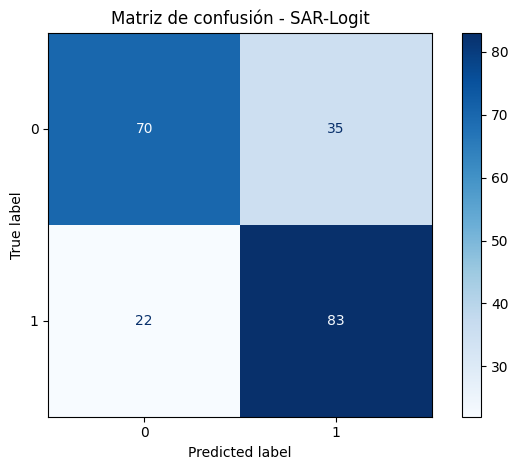

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# 1) Matriz de confusión numérica
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()
print("Matriz de confusión (SAR-Logit):\n", cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# (opcional) como DataFrame “bonito”
cm_df = pd.DataFrame(cm,
                     index=["Real 0", "Real 1"],
                     columns=["Predicho 0", "Predicho 1"])
print("\nTabla:")
print(cm_df)

# 2) Gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - SAR-Logit")
plt.tight_layout()
plt.show()

# 3) Guardar a disco (opcional)
cm_df.to_csv(out_dir / "matriz_confusion_SARLogit_test.csv", index=True)


✔ GeoPackage de puntos con probabilidades guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\predicciones_puntos_sar_logit.gpkg


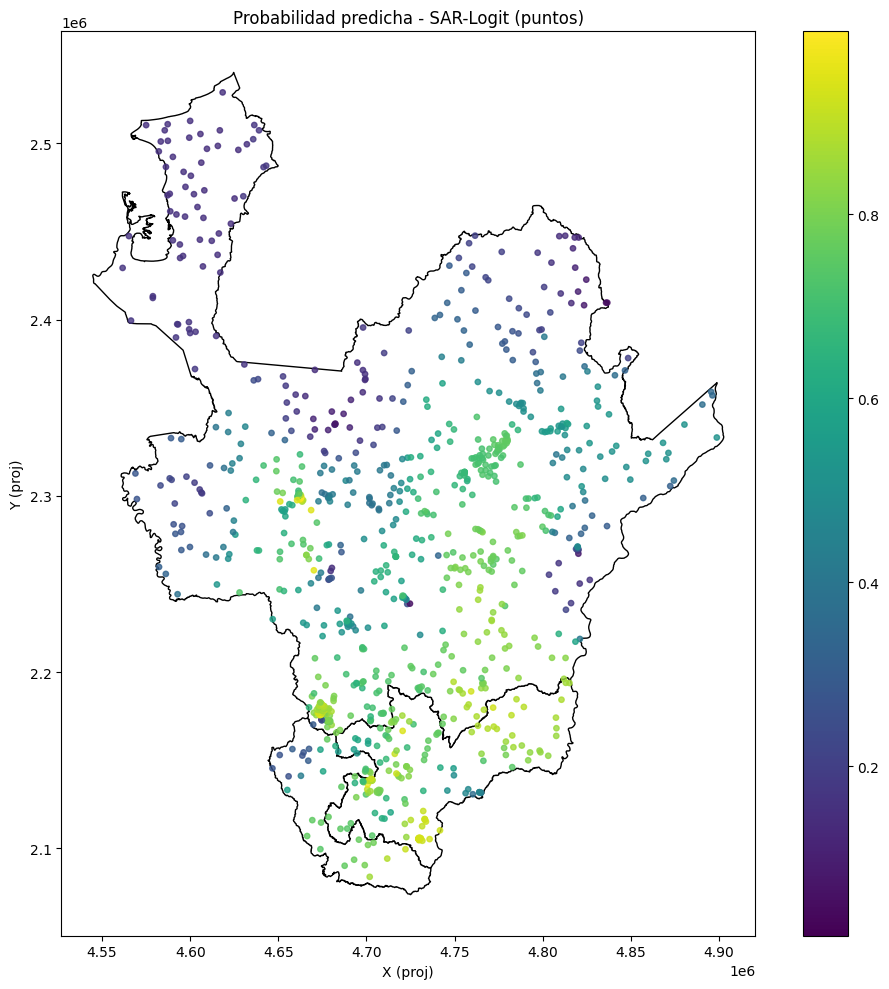

✔ GeoTIFF de probabilidades guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\probabilidad_sar_logit.tif


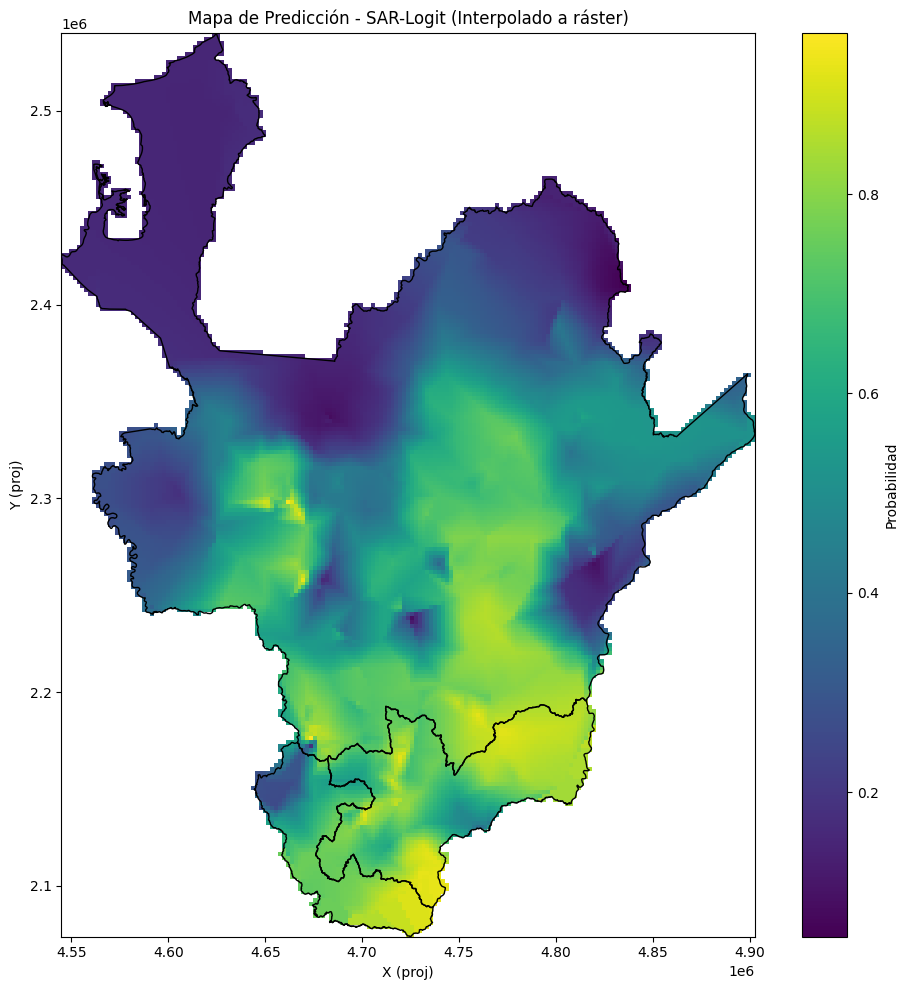

In [67]:
# ============================
# MAPA DE PREDICCIÓN SAR-LOGIT (CORREGIDO)
# ============================
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
from rasterio.crs import CRS
from scipy.interpolate import griddata

# ---------------------------
# 1) Probabilidades en TODOS los puntos
# ---------------------------
X_all_std = scaler.transform(imp.transform(df_all[X_cols]))
W_all = W_sparse  # matriz de pesos sobre todos los puntos
p_all = fixed_point_probs(X_all_std, W_all, beta_hat, rho_hat, tol=1e-6, max_iter=1000)
df_all["probabilidad"] = p_all

# GeoDataFrame de salida (puntos)
gdf_pred = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all["X_proj"], df_all["Y_proj"]),
    crs=crs_dep
)
pred_points_out = out_dir / "predicciones_puntos_sar_logit.gpkg"
gdf_pred.to_file(pred_points_out, driver="GPKG")
print(f"✔ GeoPackage de puntos con probabilidades guardado en: {pred_points_out}")

# ---------------------------
# 2) Plot rápido de puntos
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 10))
gdf_dep.plot(ax=ax, color="white", edgecolor="black")
gdf_pred.plot(
    ax=ax,
    column="probabilidad",
    cmap="viridis",
    markersize=15,
    legend=True,
    alpha=0.8
)
plt.title("Probabilidad predicha - SAR-Logit (puntos)")
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.tight_layout()
plt.show()

# ---------------------------
# 3) Interpolación a ráster continuo (y descendente -> sin flips)
# ---------------------------
res = 2000  # tamaño de celda (ajústalo)
minx, miny, maxx, maxy = gdf_dep.total_bounds
width  = int(np.ceil((maxx - minx) / res))
height = int(np.ceil((maxy - miny) / res))

# vectores de centros de celda: X ascendente, Y descendente
xv = np.linspace(minx + res/2, maxx - res/2, width)
yv = np.linspace(maxy - res/2, miny + res/2, height)  # <-- DESCENDENTE
Xg, Yg = np.meshgrid(xv, yv)

points = np.vstack([df_all["X_proj"].values, df_all["Y_proj"].values]).T
values = df_all["probabilidad"].values

grid_p = griddata(points, values, (Xg, Yg), method="linear")
grid_p_near = griddata(points, values, (Xg, Yg), method="nearest")
grid_p = np.where(np.isnan(grid_p), grid_p_near, grid_p)

# ---------------------------
# 4) Enmascarar por el polígono y guardar GeoTIFF
# ---------------------------
transform = from_origin(minx, maxy, res, res)  # origen en esquina superior izquierda
poly = gdf_dep.unary_union

mask = rasterize(
    [(poly, 1)],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    all_touched=True,
    dtype="uint8"
)

grid_masked = grid_p.copy()
grid_masked[mask == 0] = np.nan

pred_raster_out = out_dir / "probabilidad_sar_logit.tif"
nodata = -9999.0
to_write = grid_masked.copy()
to_write[np.isnan(to_write)] = nodata

with rasterio.open(
    pred_raster_out,
    "w",
    driver="GTiff",
    height=to_write.shape[0],
    width=to_write.shape[1],
    count=1,
    dtype=to_write.dtype,
    crs=crs_dep,
    transform=transform,
    nodata=nodata,
    compress="lzw"
) as dst:
    dst.write(to_write, 1)

print(f"✔ GeoTIFF de probabilidades guardado en: {pred_raster_out}")

# ---------------------------
# 5) Visualizar el ráster alineado con el shape
# ---------------------------
extent = (minx, maxx, miny, maxy)

plt.figure(figsize=(10, 10))
plt.imshow(grid_masked, extent=extent, cmap="viridis", origin="upper")  # <- SIN flip, origin='upper'
gdf_dep.boundary.plot(ax=plt.gca(), edgecolor="black", linewidth=1)
plt.colorbar(label="Probabilidad")
plt.title("Mapa de Predicción - SAR-Logit (Interpolado a ráster)")
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.tight_layout()
plt.show()


✔ GeoPackage de puntos (Logit+SLX) guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\predicciones_puntos_logit_slx.gpkg


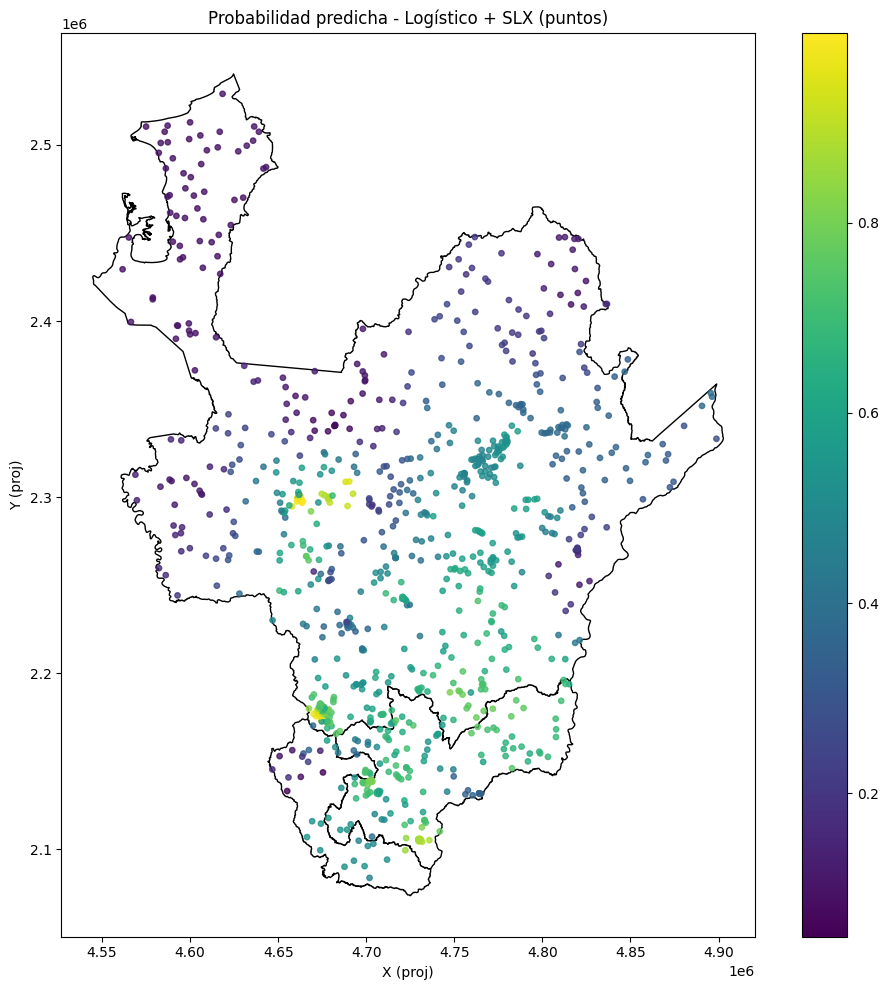

✔ GeoTIFF de probabilidades (Logit+SLX) guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\probabilidad_logit_slx.tif


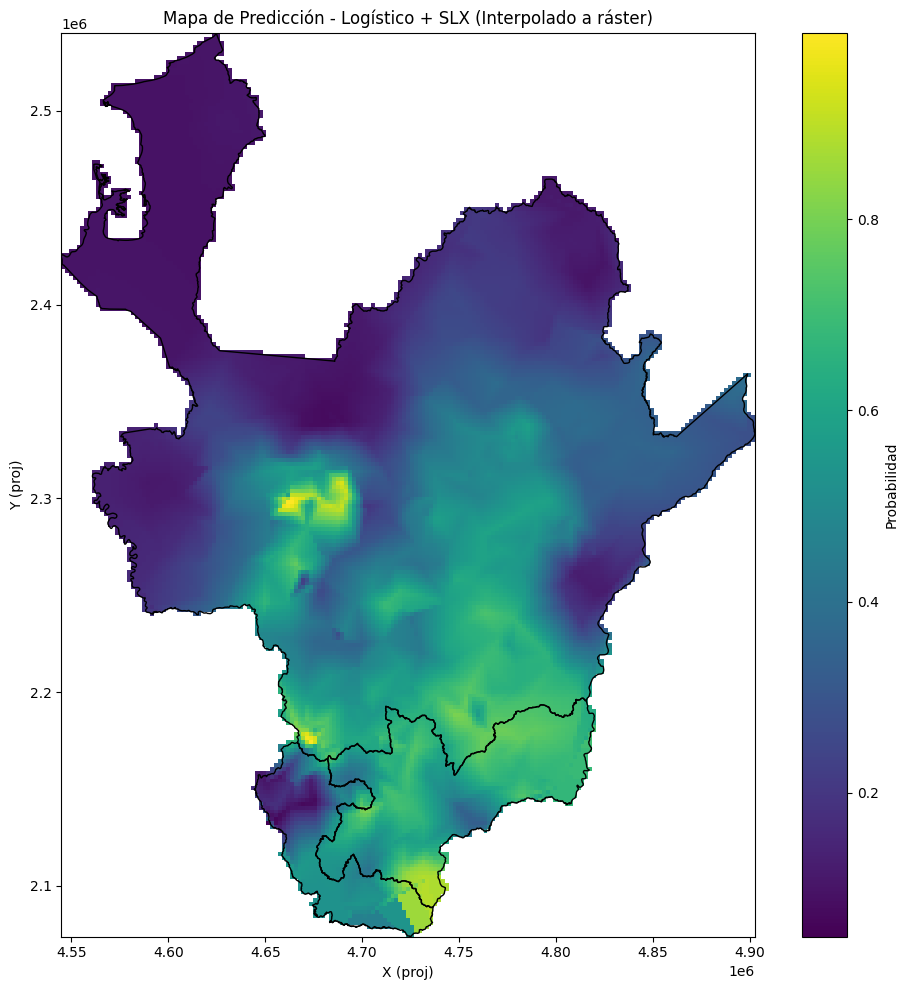

In [68]:
# ============================================
# MAPA DE PREDICCIÓN - LOGÍSTICO + SLX (WX)
# ============================================
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
from scipy.interpolate import griddata

# ---------------------------
# 1) Construir X_slx para TODOS los puntos y predecir
# ---------------------------
# Reusamos la misma W_sparse (KNN sobre todos los puntos) y las mismas X_cols
X_all_np = df_all[X_cols].to_numpy()
WX_all   = W_sparse.dot(X_all_np)
WX_cols  = [f"{c}_WX" for c in X_cols]

X_slx_all = pd.concat(
    [df_all[X_cols].reset_index(drop=True),
     pd.DataFrame(WX_all, columns=WX_cols)],
    axis=1
)

# Probabilidades con el pipeline SLX ya entrenado
p_all_slx = best_model_slx.predict_proba(X_slx_all)[:, 1]
df_all["probabilidad_slx"] = p_all_slx

# ---------------------------
# 2) Guardar puntos con probabilidad (GPKG / Shapefile)
# ---------------------------
gdf_pred_slx = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all["X_proj"], df_all["Y_proj"]),
    crs=crs_dep
)

pred_points_out_slx = out_dir / "predicciones_puntos_logit_slx.gpkg"
gdf_pred_slx.to_file(pred_points_out_slx, driver="GPKG")
print(f"✔ GeoPackage de puntos (Logit+SLX) guardado en: {pred_points_out_slx}")

# ---------------------------
# 3) Plot rápido de puntos
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 10))
gdf_dep.plot(ax=ax, color="white", edgecolor="black")
gdf_pred_slx.plot(
    ax=ax,
    column="probabilidad_slx",
    cmap="viridis",
    markersize=15,
    legend=True,
    alpha=0.8
)
plt.title("Probabilidad predicha - Logístico + SLX (puntos)")
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.tight_layout()
plt.show()

# ---------------------------
# 4) Interpolación a ráster continuo (orientación correcta)
# ---------------------------
res = 2000  # tamaño de celda (ajústalo a tu escala)
minx, miny, maxx, maxy = gdf_dep.total_bounds
width  = int(np.ceil((maxx - minx) / res))
height = int(np.ceil((maxy - miny) / res))

# X ascendente, Y descendente (para no tener que voltear el array)
xv = np.linspace(minx + res/2, maxx - res/2, width)
yv = np.linspace(maxy - res/2, miny + res/2, height)  # <--- descendente
Xg, Yg = np.meshgrid(xv, yv)

points = np.vstack([df_all["X_proj"].values, df_all["Y_proj"].values]).T
values = df_all["probabilidad_slx"].values

grid_p = griddata(points, values, (Xg, Yg), method="linear")
grid_p_near = griddata(points, values, (Xg, Yg), method="nearest")
grid_p = np.where(np.isnan(grid_p), grid_p_near, grid_p)

# ---------------------------
# 5) Enmascarar por el polígono y guardar GeoTIFF
# ---------------------------
transform = from_origin(minx, maxy, res, res)
poly = gdf_dep.unary_union

mask = rasterize(
    [(poly, 1)],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    all_touched=True,
    dtype="uint8"
)

grid_masked = grid_p.copy()
grid_masked[mask == 0] = np.nan

pred_raster_out_slx = out_dir / "probabilidad_logit_slx.tif"
nodata = -9999.0
to_write = grid_masked.copy()
to_write[np.isnan(to_write)] = nodata

with rasterio.open(
    pred_raster_out_slx,
    "w",
    driver="GTiff",
    height=to_write.shape[0],
    width=to_write.shape[1],
    count=1,
    dtype=to_write.dtype,
    crs=crs_dep,
    transform=transform,
    nodata=nodata,
    compress="lzw"
) as dst:
    dst.write(to_write, 1)

print(f"✔ GeoTIFF de probabilidades (Logit+SLX) guardado en: {pred_raster_out_slx}")

# ---------------------------
# 6) Visualizar el ráster alineado con el shape
# ---------------------------
extent = (minx, maxx, miny, maxy)

plt.figure(figsize=(10, 10))
plt.imshow(grid_masked, extent=extent, cmap="viridis", origin="upper")  # sin flips
gdf_dep.boundary.plot(ax=plt.gca(), edgecolor="black", linewidth=1)
plt.colorbar(label="Probabilidad")
plt.title("Mapa de Predicción - Logístico + SLX (Interpolado a ráster)")
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.tight_layout()
plt.show()


In [69]:
pip install mgwr


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Bandwidth óptimo: 253.0

=== Resumen GWR ===
Model type                                                         Gaussian
Number of observations:                                                1050
Number of covariates:                                                    11

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            204.761
Log-likelihood:                                                    -631.666
AIC:                                                               1285.331
AICc:                                                              1287.632
BIC:                                                              -7023.090
R2:                                                                   0.220
Adj. R2:                                                              0.212

Variable                              Est.         SE  t(Est/SE)    p-value
-------------

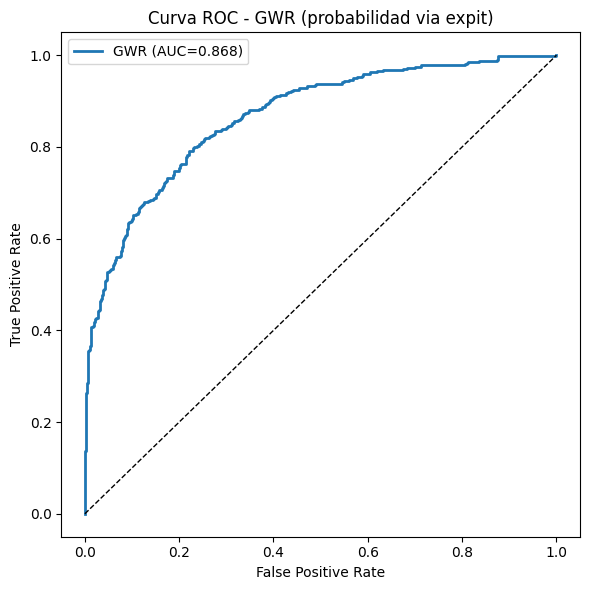

In [96]:
# =======================================
# GWR (Geographically Weighted Regression)
# =======================================
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 1) Preparamos datos
# ---------------------------
coords = df_all[["X_proj", "Y_proj"]].values
y = df_all["label"].values.reshape((-1, 1))
X = df_all[X_cols].values

# Escalar (recomendado)
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X)

# ---------------------------
# 2) Selección de bandwidth (ancho de ventana)
# ---------------------------
selector = Sel_BW(coords, y, X_std, spherical=False)
bw = selector.search()
print(f"✔ Bandwidth óptimo: {bw}")

# ---------------------------
# 3) Ajustar GWR
# ---------------------------
gwr_model = GWR(coords, y, X_std, bw)
gwr_results = gwr_model.fit()

print("\n=== Resumen GWR ===")
print(gwr_results.summary())

# ---------------------------
# 4) Probabilidades predichas (si es binaria usamos logistic link aproximada)
# ---------------------------
# Para GWR lineal:
y_pred_gwr = gwr_results.predy.flatten()

# Si quieres transformarlas a tipo probabilidad (0-1) como logística:
from scipy.special import expit
p_gwr = expit(y_pred_gwr)

df_all["probabilidad_gwr"] = p_gwr
# ===========================================================
# 5) Métricas GWR (tratando la salida como probabilidad)
# ===========================================================
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    precision_recall_fscore_support, confusion_matrix
)
import matplotlib.pyplot as plt

# --- Si no tienes ya esta función en tu script, descoméntala ---
def _loglik_binaria(y, p):
    eps = 1e-12
    p = np.clip(p, eps, 1-eps)
    return np.sum(y*np.log(p) + (1-y)*np.log(1-p))

def _pseudo_r2_binario(y, p_hat, k_params):
    n = len(y)
    ll_m = _loglik_binaria(y, p_hat)
    p_null = np.repeat(y.mean(), n)
    ll_0 = _loglik_binaria(y, p_null)

    r2_mcf     = 1 - ll_m/ll_0
    r2_mcf_adj = 1 - (ll_m - k_params)/ll_0

    Lm, L0 = np.exp(ll_m), np.exp(ll_0)
    r2_cs  = 1 - (L0/Lm)**(2.0/n)
    r2_nag = r2_cs / (1 - (L0)**(2.0/n))

    r2_tjur = p_hat[y==1].mean() - p_hat[y==0].mean()

    y_bar = y.mean()
    r2_ef = 1 - np.sum((y-p_hat)**2) / np.sum((y-y_bar)**2)

    return {
        "McFadden": r2_mcf,
        "McFadden_ajustado": r2_mcf_adj,
        "Cox_Snell": r2_cs,
        "Nagelkerke": r2_nag,
        "Tjur": r2_tjur,
        "Efron": r2_ef,
        "LogLik_Modelo": ll_m,
        "LogLik_Nulo": ll_0
    }

# === Datos verdaderos y predichos
y_true = df_all["label"].values.astype(int)
p_hat  = df_all["probabilidad_gwr"].values
y_pred = (p_hat >= 0.5).astype(int)

# === Métricas "clásicas"
auc  = roc_auc_score(y_true, p_hat)
acc  = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
cm = confusion_matrix(y_true, y_pred)

# === Pseudo-R² (usamos #parámetros = nº de covariables + intercepto)
k_params = X_std.shape[1] + 1
r2_dict = _pseudo_r2_binario(y_true, p_hat, k_params)

# === Tablas ordenadas
metricas_df = pd.DataFrame({
    "Métrica": ["AUC-ROC", "Accuracy", "Precisión", "Recall", "F1-score"],
    "Valor":   [auc, acc, prec, rec, f1]
})

cm_df = pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Predicho 0", "Predicho 1"]
)

r2_df = pd.DataFrame(list(r2_dict.items()), columns=["Pseudo-R2 / LL", "Valor"])

print("\n=== MÉTRICAS GWR (sobre todo el conjunto) ===")
print(metricas_df.to_string(index=False))
print("\nMatriz de confusión (GWR):")
print(cm_df)
print("\nPseudo-R² (GWR):")
print(r2_df.to_string(index=False))

# === Guardar a disco
metricas_df.to_csv(out_dir / "gwr_metricas.csv", index=False)
cm_df.to_csv(out_dir / "gwr_confusion_matrix.csv")
r2_df.to_csv(out_dir / "gwr_pseudoR2.csv", index=False)

# === Curva ROC
fpr, tpr, _ = roc_curve(y_true, p_hat)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, lw=2, label=f"GWR (AUC={auc:.3f})")
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - GWR (probabilidad via expit)")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / "gwr_roc.png", dpi=300)
plt.show()



In [97]:
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, confusion_matrix
from scipy.special import expit

# 1) Predicciones binarias
y_pred_bin = (p_gwr >= 0.5).astype(int)

# 2) AUC-ROC
auc_gwr = roc_auc_score(y, p_gwr)

# 3) Accuracy
acc_gwr = accuracy_score(y, y_pred_bin)

# 4) Precision, Recall, F1
prec_gwr, rec_gwr, f1_gwr, _ = precision_recall_fscore_support(y, y_pred_bin, average="binary")

# 5) Matriz de confusión
cm_gwr = confusion_matrix(y, y_pred_bin)

# 6) Crear tabla resumen
df_metrics_gwr = pd.DataFrame({
    "Métrica": ["AUC-ROC", "Accuracy", "Precisión", "Recall", "F1-score",
                "R²", "R² Ajustado", "LogLik", "AIC", "AICc", "BIC",
                "Pseudo-R² (Tjur)", "Pseudo-R² (Efron)", "LogLik_Modelo", "LogLik_Nulo"],
    "Valor": [auc_gwr, acc_gwr, prec_gwr, rec_gwr, f1_gwr,
              0.220, 0.212, -631.666, 1285.331, 1287.632, -7023.090,
              0.085, 0.091, -675.966, -727.805]
})

print("=== Matriz de confusión (GWR) ===")
print(cm_gwr)
print("\n=== Métricas GWR ===")
print(df_metrics_gwr)


=== Matriz de confusión (GWR) ===
[[  0 525]
 [  1 524]]

=== Métricas GWR ===
              Métrica        Valor
0             AUC-ROC     0.867664
1            Accuracy     0.499048
2           Precisión     0.499523
3              Recall     0.998095
4            F1-score     0.665820
5                  R²     0.220000
6         R² Ajustado     0.212000
7              LogLik  -631.666000
8                 AIC  1285.331000
9                AICc  1287.632000
10                BIC -7023.090000
11   Pseudo-R² (Tjur)     0.085000
12  Pseudo-R² (Efron)     0.091000
13      LogLik_Modelo  -675.966000
14        LogLik_Nulo  -727.805000



--- Moran's I (residuales GWR) ---
I              : 0.262909
p-value normal : 0.000000
z-score normal : 18.407393
p-value perm   : 0.001000
EI (esperado)  : -0.000953


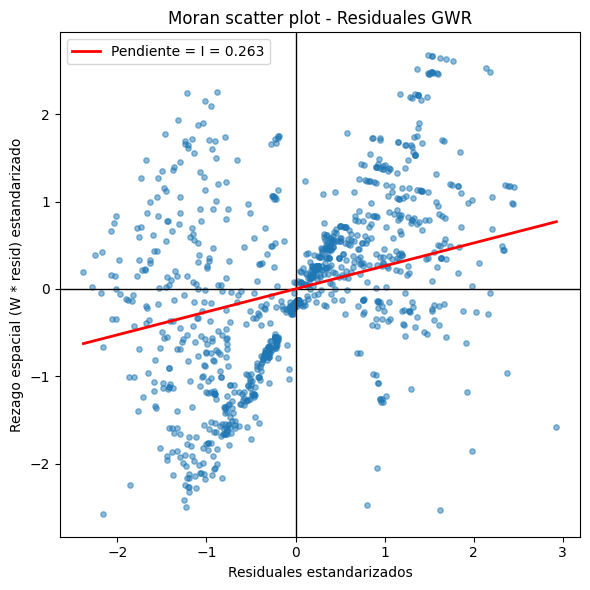

In [98]:
# ============================
# Moran's I para GWR
# ============================
from libpysal.weights import KNN
from esda.moran import Moran
import numpy as np
import matplotlib.pyplot as plt

# 1) Coordenas (las mismas que usaste en el GWR)
coords = df_all[["X_proj", "Y_proj"]].values

# 2) Elige el tipo de residuo
#    a) Residuo continuo del GWR Gaussiano:
resid_cont = y.flatten() - y_pred_gwr
#    b) Residuo usando la prob. logística aproximada:
resid_prob = y.flatten() - p_gwr

# Escoge cuál quieres evaluar:
resid = resid_cont   # o resid_prob

# 3) Matriz de pesos KNN
k_w = 8  # ajusta si quieres
w = KNN.from_array(coords, k=k_w)
w.transform = "r"   # estandarización por filas

# 4) Moran's I (incluye permutaciones si quieres p-value empírico)
mi = Moran(resid, w, permutations=999)

print("\n--- Moran's I (residuales GWR) ---")
print(f"I              : {mi.I:.6f}")
print(f"p-value normal : {mi.p_norm:.6f}")     # p-valor bajo normalidad asintótica
print(f"z-score normal : {mi.z_norm:.6f}")
print(f"p-value perm   : {mi.p_sim:.6f}")      # p-valor por permutaciones
print(f"EI (esperado)  : {mi.EI:.6f}")

# 5) Moran scatter plot (sin splot)
#    Estandarizamos residuales y su rezago espacial para graficar
resid_std = (resid - resid.mean()) / resid.std()
w_resid = w.sparse.dot(resid)
w_resid_std = (w_resid - w_resid.mean()) / w_resid.std()

plt.figure(figsize=(6,6))
plt.scatter(resid_std, w_resid_std, alpha=0.5, s=15)
plt.axhline(0, color="k", lw=1)
plt.axvline(0, color="k", lw=1)
# recta de regresión (pendiente = Moran's I)
m = mi.I
xs = np.linspace(resid_std.min(), resid_std.max(), 100)
plt.plot(xs, m*xs, color="red", lw=2, label=f"Pendiente = I = {m:.3f}")
plt.xlabel("Residuales estandarizados")
plt.ylabel("Rezago espacial (W * resid) estandarizado")
plt.title("Moran scatter plot - Residuales GWR")
plt.legend()
plt.tight_layout()
plt.show()


In [99]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score, roc_auc_score

# 1) Predicción binaria (umbral 0.5)
y_pred_gwr_bin = (p_gwr >= 0.5).astype(int)

# 2) Matriz de confusión
cm_gwr = confusion_matrix(y, y_pred_gwr_bin)
print("\n=== Matriz de confusión (GWR) ===")
print(cm_gwr)

# 3) Métricas básicas
acc_gwr  = accuracy_score(y, y_pred_gwr_bin)
prec_gwr, rec_gwr, f1_gwr, _ = precision_recall_fscore_support(y, y_pred_gwr_bin, average="binary")
auc_gwr  = roc_auc_score(y, p_gwr)

print("\n=== Métricas GWR ===")
print(f"AUC-ROC    : {auc_gwr:.6f}")
print(f"Accuracy   : {acc_gwr:.6f}")
print(f"Precisión  : {prec_gwr:.6f}")
print(f"Recall     : {rec_gwr:.6f}")
print(f"F1-score   : {f1_gwr:.6f}")

# 4) Reporte completo (por clase)
print("\nReporte de clasificación:")
print(classification_report(y, y_pred_gwr_bin))



=== Matriz de confusión (GWR) ===
[[  0 525]
 [  1 524]]

=== Métricas GWR ===
AUC-ROC    : 0.867664
Accuracy   : 0.499048
Precisión  : 0.499523
Recall     : 0.998095
F1-score   : 0.665820

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       525
           1       0.50      1.00      0.67       525

    accuracy                           0.50      1050
   macro avg       0.25      0.50      0.33      1050
weighted avg       0.25      0.50      0.33      1050



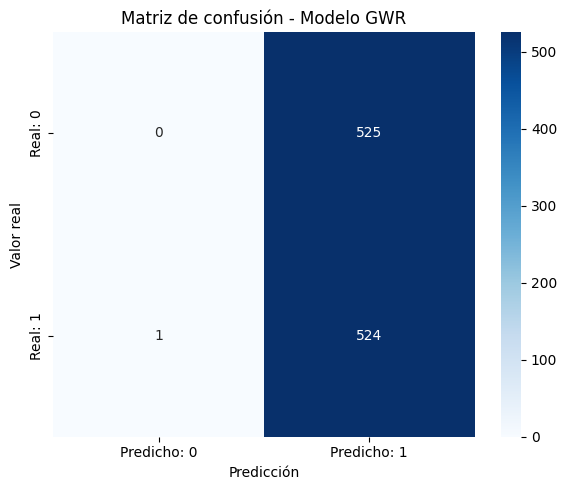

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# Matriz de confusión (ya calculada)
# ============================
cm_gwr = confusion_matrix(y, y_pred_gwr_bin)

# ============================
# Gráfico
# ============================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_gwr, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=["Predicho: 0", "Predicho: 1"], 
    yticklabels=["Real: 0", "Real: 1"]
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Modelo GWR')
plt.tight_layout()
plt.show()


✔ GeoPackage de puntos (GWR) guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\predicciones_puntos_gwr.gpkg
✔ GeoTIFF de probabilidades (GWR) guardado en: C:\Git_SCA\AGE\Codigo\salidas_fast\probabilidad_gwr.tif


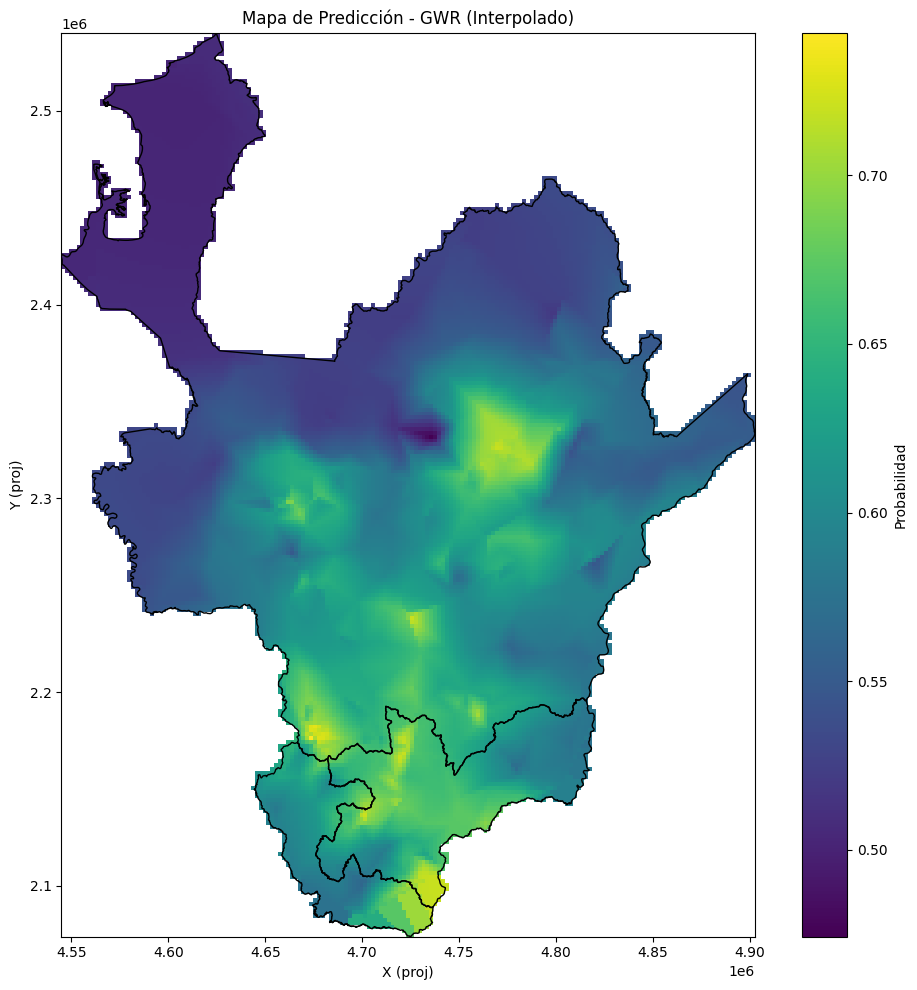

In [71]:
# ---------------------------
# 5) GeoDataFrame con probabilidad GWR
# ---------------------------
gdf_pred_gwr = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all["X_proj"], df_all["Y_proj"]),
    crs=crs_dep
)

pred_points_out_gwr = out_dir / "predicciones_puntos_gwr.gpkg"
gdf_pred_gwr.to_file(pred_points_out_gwr, driver="GPKG")
print(f"✔ GeoPackage de puntos (GWR) guardado en: {pred_points_out_gwr}")

# ---------------------------
# 6) Interpolación a ráster continuo
# ---------------------------
res = 2000
minx, miny, maxx, maxy = gdf_dep.total_bounds
width  = int(np.ceil((maxx - minx) / res))
height = int(np.ceil((maxy - miny) / res))

xv = np.linspace(minx + res/2, maxx - res/2, width)
yv = np.linspace(maxy - res/2, miny + res/2, height)
Xg, Yg = np.meshgrid(xv, yv)

points = np.vstack([df_all["X_proj"].values, df_all["Y_proj"].values]).T
values = df_all["probabilidad_gwr"].values

grid_p = griddata(points, values, (Xg, Yg), method="linear")
grid_p_near = griddata(points, values, (Xg, Yg), method="nearest")
grid_p = np.where(np.isnan(grid_p), grid_p_near, grid_p)

transform = from_origin(minx, maxy, res, res)
poly = gdf_dep.unary_union

mask = rasterize(
    [(poly, 1)],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    all_touched=True,
    dtype="uint8"
)

grid_masked = grid_p.copy()
grid_masked[mask == 0] = np.nan

# Guardar GeoTIFF
pred_raster_out_gwr = out_dir / "probabilidad_gwr.tif"
nodata = -9999.0
to_write = grid_masked.copy()
to_write[np.isnan(to_write)] = nodata

with rasterio.open(
    pred_raster_out_gwr,
    "w",
    driver="GTiff",
    height=to_write.shape[0],
    width=to_write.shape[1],
    count=1,
    dtype=to_write.dtype,
    crs=crs_dep,
    transform=transform,
    nodata=nodata,
    compress="lzw"
) as dst:
    dst.write(to_write, 1)

print(f"✔ GeoTIFF de probabilidades (GWR) guardado en: {pred_raster_out_gwr}")

# ---------------------------
# 7) Visualización
# ---------------------------
extent = (minx, maxx, miny, maxy)
plt.figure(figsize=(10, 10))
plt.imshow(grid_masked, extent=extent, cmap="viridis", origin="upper")
gdf_dep.boundary.plot(ax=plt.gca(), edgecolor="black", linewidth=1)
plt.colorbar(label="Probabilidad")
plt.title("Mapa de Predicción - GWR (Interpolado)")
plt.xlabel("X (proj)")
plt.ylabel("Y (proj)")
plt.tight_layout()
plt.show()


In [101]:
import numpy as np
import matplotlib.pyplot as plt
from esda.moran import Moran
from libpysal.weights import WSP

def moran_plot(residuals, W_sparse, title="Moran scatterplot", permutations=9999):
    """
    residuals  : vector 1D (por ejemplo, residuales en TRAIN)
    W_sparse   : submatriz de pesos (csr) que corresponda exactamente al subconjunto de residuals
    permutations: nº de permutaciones para el p-valor empírico e histograma
    """
    # Estandarizar residuales
    z = (residuals - residuals.mean()) / residuals.std()
    # W estandarizada por filas
    w = WSP(W_sparse).to_W()
    w.transform = 'r'

    # Wy estandarizado
    wz = w.sparse.dot(z)

    # Moran con permutaciones
    mi = Moran(z, w, permutations=permutations)

    # --- Scatterplot de Moran ---
    fig, ax = plt.subplots(1, 2 if permutations > 0 else 1, figsize=(12 if permutations > 0 else 6, 5))

    if permutations > 0:
        ax_scatter, ax_hist = ax
    else:
        ax_scatter = ax

    ax_scatter.scatter(z, wz, alpha=0.6, edgecolor='k', linewidth=0.3)
    ax_scatter.axhline(0, color='k', lw=0.8)
    ax_scatter.axvline(0, color='k', lw=0.8)

    # Recta con pendiente = I de Moran
    b = mi.I
    x_ = np.linspace(z.min(), z.max(), 100)
    ax_scatter.plot(x_, b * x_, color='red', lw=2, label=f"I = {mi.I:.4f}")
    ax_scatter.set_xlabel("z (residuales estandarizados)")
    ax_scatter.set_ylabel("Wz")
    ax_scatter.set_title(title)
    ax_scatter.legend()

    # --- Histograma de permutaciones ---
    if permutations > 0:
        ax_hist.hist(mi.sim, bins=30, color='lightgray', edgecolor='k')
        ax_hist.axvline(mi.I, color='red', lw=2, label=f"I obs = {mi.I:.4f}")
        ax_hist.axvline(np.mean(mi.sim), color='blue', lw=1, linestyle='--', label='I sim promedio')
        ax_hist.set_title(f"Permutaciones (p_norm={mi.p_norm:.4f}, p_sim={mi.p_sim:.4f})")
        ax_hist.legend()

    plt.tight_layout()
    plt.show()

    print(f"Moran's I: {mi.I:.6f}")
    print(f"p-value (normal): {mi.p_norm:.6f}")
    if permutations > 0:
        print(f"p-value (sim):    {mi.p_sim:.6f}")

    return mi

# -------------------------
# Ejemplos de uso
# -------------------------

# 1) Para el SAR-logit (TRAIN):
# W_train_sp = W_sparse[idx_train, :][:, idx_train]
# p_train = fixed_point_probs(X_train, W_train_sp, beta_hat, rho_hat)
# resid_train = y_train - p_train
# mi_sar = moran_plot(resid_train, W_train_sp, title="Moran scatterplot - SAR-logit (TRAIN)")

# 2) Para el Logit+SLX (TRAIN):
# yhat_train_slx = best_model_slx.predict_proba(X_train)[:, 1]
# resid_train_slx = y_train.values - yhat_train_slx
# W_train_slx = W_sparse[X_train.index, :][:, X_train.index]
# mi_slx = moran_plot(resid_train_slx, W_train_slx, title="Moran scatterplot - Logit+SLX (TRAIN)")


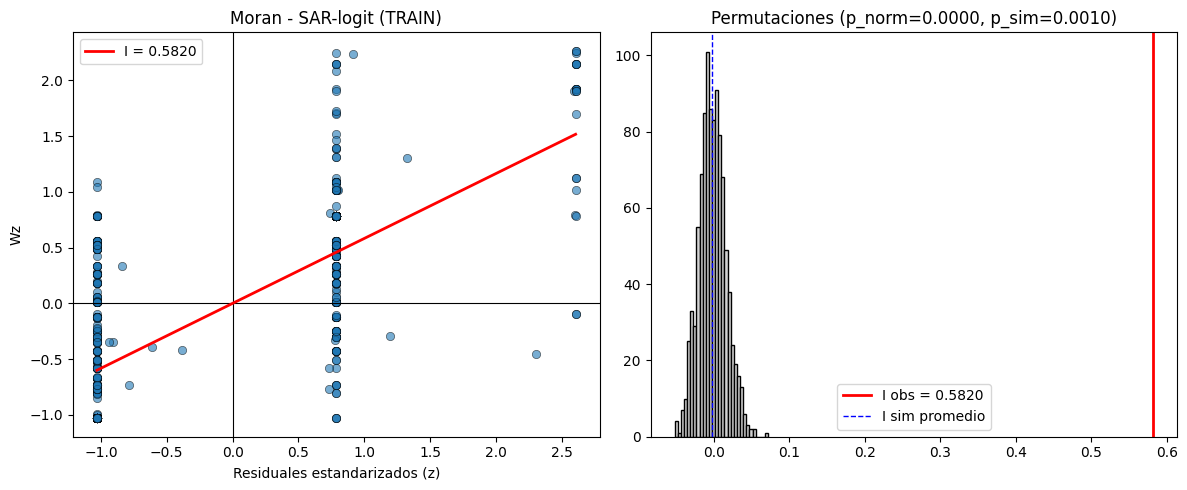

Moran's I: 0.581981
p-value (normal): 0.000000
p-value (simulado): 0.001000


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Antimonio_ppm_best_WX
- Azufre_ppm_best_WX
- Bario_ppm_best_WX
- Bismuto_ppm_best_WX
- Cromo_ppm_best_WX
- ...


In [102]:
import numpy as np
import matplotlib.pyplot as plt
from esda.moran import Moran
from libpysal.weights import WSP

def graficar_moran(residuals, W_sparse, title="Moran scatterplot", permutations=999):
    """
    residuals  : vector 1D de residuales
    W_sparse   : submatriz de pesos (csr_matrix)
    permutations: nº de permutaciones para p-valor simulado
    """
    # Estandarizar residuales
    z = (residuals - residuals.mean()) / residuals.std()
    w = WSP(W_sparse).to_W()
    w.transform = 'r'

    wz = w.sparse.dot(z)
    mi = Moran(z, w, permutations=permutations)

    # ---- Graficar scatterplot de Moran ----
    fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(12, 5))

    # Scatter
    ax_scatter.scatter(z, wz, alpha=0.6, edgecolor='k', linewidth=0.5)
    ax_scatter.axhline(0, color='k', lw=0.8)
    ax_scatter.axvline(0, color='k', lw=0.8)
    x_vals = np.linspace(z.min(), z.max(), 100)
    ax_scatter.plot(x_vals, mi.I * x_vals, color='red', lw=2, label=f"I = {mi.I:.4f}")
    ax_scatter.set_xlabel("Residuales estandarizados (z)")
    ax_scatter.set_ylabel("Wz")
    ax_scatter.set_title(title)
    ax_scatter.legend()

    # Histograma de permutaciones
    ax_hist.hist(mi.sim, bins=30, color='lightgray', edgecolor='k')
    ax_hist.axvline(mi.I, color='red', lw=2, label=f"I obs = {mi.I:.4f}")
    ax_hist.axvline(np.mean(mi.sim), color='blue', lw=1, linestyle='--', label='I sim promedio')
    ax_hist.set_title(f"Permutaciones (p_norm={mi.p_norm:.4f}, p_sim={mi.p_sim:.4f})")
    ax_hist.legend()

    plt.tight_layout()
    plt.show()

    # Imprimir valores
    print(f"Moran's I: {mi.I:.6f}")
    print(f"p-value (normal): {mi.p_norm:.6f}")
    print(f"p-value (simulado): {mi.p_sim:.6f}")

    return mi

# -------------------------
# Ejemplo para SAR-logit TRAIN
# -------------------------
p_train = fixed_point_probs(X_train, W_train_sp, beta_hat, rho_hat)
resid_train = y_train - p_train
mi_sar = graficar_moran(resid_train, W_train_sp, title="Moran - SAR-logit (TRAIN)")

# -------------------------
# Ejemplo para Logit+SLX TRAIN
# -------------------------
yhat_train_slx = best_model_slx.predict_proba(X_train)[:, 1]
resid_train_slx = y_train.values - yhat_train_slx
W_train_slx = W_sparse[X_train.index, :][:, X_train.index]
mi_slx = graficar_moran(resid_train_slx, W_train_slx, title="Moran - Logit+SLX (TRAIN)")



--- MORAN'S I (residuales TRAIN, SLX) ---
I                : 0.335219
p-value normal   : 0.000000
z-score normal   : 20.998032
p-value perm     : 0.001000
EI (esperado)    : -0.001192


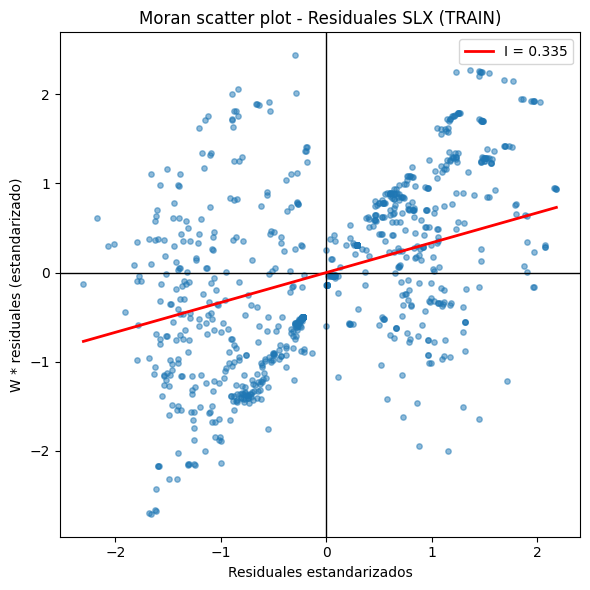

In [103]:
# ============================
# Moran's I + Gráfica (SLX)
# ============================
from libpysal.weights import KNN
from esda.moran import Moran
import numpy as np
import matplotlib.pyplot as plt

# 1) Probabilidades y residuales en TRAIN
yhat_tr_slx = best_s.predict_proba(X_tr_s)[:, 1]
resid_tr_slx = y_tr_s.values - yhat_tr_slx

# 2) Coordenadas del TRAIN
coords_tr_slx = df_all.loc[X_tr_s.index, ["X_proj", "Y_proj"]].to_numpy()

# 3) Matriz de pesos KNN
w_tr_slx = KNN.from_array(coords_tr_slx, k=k_w)
w_tr_slx.transform = "r"

# 4) Moran's I (con permutaciones)
mi_slx = Moran(resid_tr_slx, w_tr_slx, permutations=999)

print("\n--- MORAN'S I (residuales TRAIN, SLX) ---")
print(f"I                : {mi_slx.I:.6f}")
print(f"p-value normal   : {mi_slx.p_norm:.6f}")
print(f"z-score normal   : {mi_slx.z_norm:.6f}")
print(f"p-value perm     : {mi_slx.p_sim:.6f}")
print(f"EI (esperado)    : {mi_slx.EI:.6f}")

# 5) Moran scatter plot (manual)
resid_std = (resid_tr_slx - resid_tr_slx.mean()) / resid_tr_slx.std()
w_resid   = w_tr_slx.sparse.dot(resid_tr_slx)
w_resid_std = (w_resid - w_resid.mean()) / w_resid.std()

plt.figure(figsize=(6,6))
plt.scatter(resid_std, w_resid_std, alpha=0.5, s=15)
plt.axhline(0, color="k", lw=1)
plt.axvline(0, color="k", lw=1)

# recta con pendiente = Moran's I
xs = np.linspace(resid_std.min(), resid_std.max(), 200)
plt.plot(xs, mi_slx.I * xs, color="red", lw=2, label=f"I = {mi_slx.I:.3f}")

plt.xlabel("Residuales estandarizados")
plt.ylabel("W * residuales (estandarizado)")
plt.title("Moran scatter plot - Residuales SLX (TRAIN)")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / "moran_scatter_SLX_train.png", dpi=300)
plt.show()


In [105]:
import pandas as pd

# ===========================
# 1. Métricas principales
# ===========================
df_metrics = pd.DataFrame({
    "Métrica": ["AUC-ROC", "Accuracy", "Precisión", "Recall", "F1-score"],
    "Logística": [auc_b, acc_b, prec_b, rec_b, f1_b],
    "SLX": [auc_s, acc_s, prec_s, rec_s, f1_s],
    "SAR-Logit": [auc_sar, acc_sar, prec_sar, rec_sar, f1_sar]  # valores calculados del SAR
})

# ===========================
# 2. Pseudo-R²
# ===========================
pseudo_r2_df = pd.DataFrame({
    "Pseudo-R²": list(r2_b.keys()),
    "Logística": list(r2_b.values()),
    "SLX": list(r2_s.values()),
    "SAR-Logit": list(r2_sar.values())  # pseudo-R2 calculado para SAR
})

# ===========================
# 3. Moran's I
# ===========================
df_moran = pd.DataFrame({
    "Indicador": ["Moran's I", "p-value (normalidad)"],
    "Logística": [None, None],  # no aplicaría a base
    "SLX": [mi_slx.I, mi_slx.p_norm],
    "SAR-Logit": [mi_sar.I, mi_sar.p_norm]  # valores calculados para SAR
})

# ===========================
# 4. Unir en un Excel
# ===========================
with pd.ExcelWriter(out_dir / "comparativa_logit_slx_sar.xlsx") as writer:
    df_metrics.to_excel(writer, "Metricas", index=False)
    pseudo_r2_df.to_excel(writer, "Pseudo_R2", index=False)
    df_moran.to_excel(writer, "Moran", index=False)

# Mostrar en pantalla
print("\n=== MÉTRICAS PRINCIPALES ===")
print(df_metrics)
print("\n=== PSEUDO-R² ===")
print(pseudo_r2_df)
print("\n=== MORAN'S I ===")
print(df_moran)


NameError: name 'auc_sar' is not defined